# Permeability Tensor Off-Diagonal Analysis

Analysis of K_xy, K_yz, and K_xz components from the permeability tensor.
These off-diagonal components indicate anisotropy and cross-flow behavior.

**Separate analysis for each dataset:**
- 256-final.csv
- 128_final.csv

In [464]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')

# Standard plot settings (porosity histogram as reference)
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['STIX Two Text', 'Times New Roman'],
    'mathtext.fontset': 'cm',
    'font.size': 20,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})
sns.set_palette('husl')

# Target columns for analysis
target_cols = ['K_xy', 'K_yz', 'K_xz']
colors = ['#3498db', '#e74c3c', '#2ecc71']

In [465]:
def analyze_dataset(df, dataset_name):
    """
    Comprehensive analysis function for a single dataset.
    Returns statistics, plots, and extreme samples.
    """
    print("=" * 80)
    print(f"ANALYSIS: {dataset_name}")
    print(f"Total samples: {len(df)}")
    print("=" * 80)
    
    # Calculate off-diagonal magnitude
    df = df.copy()
    df['K_offdiag_magnitude'] = np.sqrt(
        df['K_xy']**2 + df['K_yz']**2 + df['K_xz']**2
    )
    
    return df


def print_statistics(df, dataset_name):
    """
    Print statistical summary for K_xy, K_yz, K_xz.
    """
    print(f"\n{'='*60}")
    print(f"STATISTICAL SUMMARY: {dataset_name}")
    print(f"{'='*60}")
    
    stats = df[target_cols].describe()
    stats.loc['range'] = stats.loc['max'] - stats.loc['min']
    stats.loc['IQR'] = stats.loc['75%'] - stats.loc['25%']
    display(stats)
    
    print("\nAdditional Statistics:")
    for col in target_cols:
        print(f"\n  {col}:")
        print(f"    Median: {df[col].median():.6f}")
        print(f"    Skewness: {df[col].skew():.4f}")
        print(f"    Kurtosis: {df[col].kurtosis():.4f}")
        print(f"    % Positive: {(df[col] > 0).mean() * 100:.2f}%")
        print(f"    % Negative: {(df[col] < 0).mean() * 100:.2f}%")
    
    return stats


def count_small_values(df, dataset_name):
    """
    Count samples with small absolute values at various thresholds.
    """
    print(f"\n{'='*80}")
    print(f"SMALL VALUE COUNTS: {dataset_name}")
    print(f"{'='*80}")
    
    total = len(df)
    
    # Thresholds to check
    thresholds = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
    
    # Create summary table for individual components
    print("\n--- Individual Component Counts (|value| < threshold) ---\n")
    
    results = []
    for thresh in thresholds:
        row = {'Threshold': f'< {thresh}'}
        for col in target_cols:
            count = (df[col].abs() < thresh).sum()
            pct = count / total * 100
            row[f'{col} Count'] = count
            row[f'{col} %'] = f'{pct:.1f}%'
        results.append(row)
    
    results_df = pd.DataFrame(results)
    display(results_df)
    
    # Create summary for magnitude (combined)
    print("\n--- Off-Diagonal Magnitude Counts (√(K_xy² + K_yz² + K_xz²) < threshold) ---\n")
    
    mag_results = []
    for thresh in thresholds:
        count = (df['K_offdiag_magnitude'] < thresh).sum()
        pct = count / total * 100
        mag_results.append({
            'Threshold': f'< {thresh}',
            'Count': count,
            'Percentage': f'{pct:.1f}%'
        })
    
    mag_df = pd.DataFrame(mag_results)
    display(mag_df)
    
    # Detailed breakdown for very small values
    print("\n--- Detailed Breakdown: Very Small Values ---\n")
    
    for col in target_cols:
        print(f"\n{col}:")
        abs_vals = df[col].abs()
        print(f"  |value| < 0.001:  {(abs_vals < 0.001).sum():5d} ({(abs_vals < 0.001).mean()*100:5.1f}%)")
        print(f"  |value| < 0.01:   {(abs_vals < 0.01).sum():5d} ({(abs_vals < 0.01).mean()*100:5.1f}%)")
        print(f"  |value| < 0.1:    {(abs_vals < 0.1).sum():5d} ({(abs_vals < 0.1).mean()*100:5.1f}%)")
        print(f"  |value| < 1.0:    {(abs_vals < 1.0).sum():5d} ({(abs_vals < 1.0).mean()*100:5.1f}%)")
    
    print(f"\nOff-diagonal Magnitude:")
    mag = df['K_offdiag_magnitude']
    print(f"  magnitude < 0.001:  {(mag < 0.001).sum():5d} ({(mag < 0.001).mean()*100:5.1f}%)")
    print(f"  magnitude < 0.01:   {(mag < 0.01).sum():5d} ({(mag < 0.01).mean()*100:5.1f}%)")
    print(f"  magnitude < 0.1:    {(mag < 0.1).sum():5d} ({(mag < 0.1).mean()*100:5.1f}%)")
    print(f"  magnitude < 1.0:    {(mag < 1.0).sum():5d} ({(mag < 1.0).mean()*100:5.1f}%)")
    
    return results_df, mag_df


def plot_small_value_distribution(df, dataset_name):
    """
    Plot cumulative distribution to visualize small values.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(f'Cumulative Distribution of Absolute Values - {dataset_name}', fontsize=20, y=1.02)
    
    # Individual components
    ax1 = axes[0]
    for i, col in enumerate(target_cols):
        sorted_vals = np.sort(df[col].abs())
        cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax1.plot(sorted_vals, cdf, color=colors[i], linewidth=2, label=col)
    
    ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50%')
    ax1.axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='90%')
    ax1.axvline(1.0, color='black', linestyle='--', alpha=0.3)
    ax1.set_xlabel('|Value|', fontsize=20)
    ax1.set_ylabel('Cumulative Proportion', fontsize=20)
    ax1.set_title('Individual Components', fontsize=20)
    ax1.set_xlim(0, df[target_cols].abs().quantile(0.95).max())
    ax1.legend(fontsize=16)
    ax1.grid(True, alpha=0.3)
    
    # Magnitude
    ax2 = axes[1]
    sorted_mag = np.sort(df['K_offdiag_magnitude'])
    cdf = np.arange(1, len(sorted_mag) + 1) / len(sorted_mag)
    ax2.plot(sorted_mag, cdf, color='purple', linewidth=2, label='Magnitude')
    
    ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50%')
    ax2.axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='90%')
    ax2.axvline(1.0, color='black', linestyle='--', alpha=0.3)
    ax2.set_xlabel('Off-diagonal Magnitude', fontsize=20)
    ax2.set_ylabel('Cumulative Proportion', fontsize=20)
    ax2.set_title('Combined Magnitude', fontsize=20)
    ax2.set_xlim(0, df['K_offdiag_magnitude'].quantile(0.95))
    ax2.legend(fontsize=16)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name}_cumulative_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_distributions(df, dataset_name):
    """
    Plot distribution histograms for K_xy, K_yz, K_xz — one figure per component.
    """
    for i, col in enumerate(target_cols):
        fig, ax = plt.subplots(figsize=(7, 5))
        data = df[col].dropna()
        
        ax.hist(data, bins=50, color=colors[i], alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.4f}')
        ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        
        ax.set_xlabel(col, fontsize=20)
        ax.set_ylabel('Frequency', fontsize=20)
        ax.set_title(f'{col} — {dataset_name}', fontsize=20)
        ax.legend(fontsize=20)
        ax.tick_params(axis='both', labelsize=20)
        
        plt.tight_layout()
        plt.savefig(f'{dataset_name}_{col}_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()


def plot_boxplot_violin(df, dataset_name):
    """
    Plot box plots and violin plots showing range and spread.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(f'Range and Spread - {dataset_name}', fontsize=20, y=1.02)
    
    # Box plot
    ax1 = axes[0]
    bp = ax1.boxplot([df[col].dropna() for col in target_cols], 
                      labels=target_cols, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Value', fontsize=20)
    ax1.set_title('Box Plot', fontsize=20)
    ax1.tick_params(axis='both', labelsize=20)
    ax1.grid(True, alpha=0.3)
    
    # Violin plot
    ax2 = axes[1]
    parts = ax2.violinplot([df[col].dropna() for col in target_cols], 
                            positions=[1, 2, 3], showmeans=True, showmedians=True)
    
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
    
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.set_xticks([1, 2, 3])
    ax2.set_xticklabels(target_cols)
    ax2.set_ylabel('Value', fontsize=20)
    ax2.set_title('Violin Plot', fontsize=20)
    ax2.tick_params(axis='both', labelsize=20)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name}_boxplot_violin.png', dpi=300, bbox_inches='tight')
    plt.show()



def plot_boxplot_violin_diag(df, dataset_name):
    """
    Plot box plots and violin plots showing range and spread for diagonal components.
    """
    diag_cols = ['K_xx', 'K_yy', 'K_zz']
    diag_colors = ['#e74c3c', '#2ecc71', '#3498db']

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(f'Range and Spread (Diagonal) - {dataset_name}', fontsize=20, y=1.02)

    # Box plot
    ax1 = axes[0]
    bp = ax1.boxplot([df[col].dropna() for col in diag_cols],
                      labels=diag_cols, patch_artist=True)

    for patch, color in zip(bp['boxes'], diag_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax1.set_ylabel('Value', fontsize=20)
    ax1.set_title('Box Plot', fontsize=20)
    ax1.tick_params(axis='both', labelsize=20)
    ax1.grid(True, alpha=0.3)

    # Violin plot
    ax2 = axes[1]
    parts = ax2.violinplot([df[col].dropna() for col in diag_cols],
                            positions=[1, 2, 3], showmeans=True, showmedians=True)

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(diag_colors[i])
        pc.set_alpha(0.7)

    ax2.set_xticks([1, 2, 3])
    ax2.set_xticklabels(diag_cols)
    ax2.set_ylabel('Value', fontsize=20)
    ax2.set_title('Violin Plot', fontsize=20)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{dataset_name}_diag_boxplot_violin.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_scatter_relationships(df, dataset_name):
    """
    Plot scatter relationships between components.
    """
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.suptitle(f'Pairwise Relationships - {dataset_name}', fontsize=20, y=1.02)
    
    pairs = [('K_xy', 'K_yz'), ('K_yz', 'K_xz'), ('K_xz', 'K_xy')]
    
    for i, (x_col, y_col) in enumerate(pairs):
        ax = axes[i]
        ax.scatter(df[x_col], df[y_col], alpha=0.5, c=colors[i], s=10)
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.axvline(0, color='black', linestyle='--', alpha=0.3)
        
        corr = df[x_col].corr(df[y_col])
        ax.text(0.05, 0.95, f'r = {corr:.4f}', transform=ax.transAxes, 
                fontsize=16, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel(x_col, fontsize=20)
        ax.set_ylabel(y_col, fontsize=20)
        ax.set_title(f'{x_col} vs {y_col}', fontsize=20)
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name}_scatter_plots.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_porosity_correlation(df, dataset_name):
    """
    Plot correlation between porosity and off-diagonal components.
    """
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.suptitle(f'Porosity Correlation - {dataset_name}', fontsize=20, y=1.02)
    
    for i, col in enumerate(target_cols):
        ax = axes[i]
        ax.scatter(df['porosity'], df[col], alpha=0.5, c=colors[i], s=10)
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        
        corr = df['porosity'].corr(df[col])
        ax.text(0.05, 0.95, f'r = {corr:.4f}', transform=ax.transAxes, 
                fontsize=16, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel('Porosity', fontsize=20)
        ax.set_ylabel(col, fontsize=20)
        ax.set_title(f'{col} vs Porosity', fontsize=20)
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name}_porosity_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()


def get_extreme_samples(df, dataset_name, n_samples=15):
    """
    Identify samples with extremely low and high off-diagonal values.
    Returns DataFrames for low and high extreme samples.
    """
    df_sorted = df.sort_values('K_offdiag_magnitude')
    
    display_cols = ['sample_name', 'porosity', 'K_xy', 'K_yz', 'K_xz', 
                    'K_xx', 'K_yy', 'K_zz', 'K_offdiag_magnitude']
    
    # Low extreme samples
    low_samples = df_sorted.head(n_samples)[display_cols].copy()
    low_samples = low_samples.reset_index(drop=True)
    low_samples.index = low_samples.index + 1
    
    # High extreme samples
    high_samples = df_sorted.tail(n_samples)[display_cols].copy()
    high_samples = high_samples.iloc[::-1]
    high_samples = high_samples.reset_index(drop=True)
    high_samples.index = high_samples.index + 1
    
    print(f"\n{'='*80}")
    print(f"EXTREME SAMPLES: {dataset_name}")
    print(f"{'='*80}")
    
    print(f"\n--- {n_samples} Samples with LOWEST Off-Diagonal Values (Most Isotropic) ---")
    display(low_samples)
    
    print(f"\n--- {n_samples} Samples with HIGHEST Off-Diagonal Values (Most Anisotropic) ---")
    display(high_samples)
    
    return low_samples, high_samples


def plot_extreme_samples_distribution(df, low_samples, high_samples, dataset_name):
    """
    Visualize extreme samples on the magnitude distribution.
    """
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.hist(df['K_offdiag_magnitude'], bins=50, color='gray', alpha=0.6, 
            edgecolor='black', linewidth=0.5, label='All samples')
    
    low_threshold = low_samples['K_offdiag_magnitude'].max()
    ax.axvline(low_threshold, color='blue', linestyle='--', linewidth=2, 
               label=f'Low threshold: {low_threshold:.4f}')
    
    high_threshold = high_samples['K_offdiag_magnitude'].min()
    ax.axvline(high_threshold, color='red', linestyle='--', linewidth=2, 
               label=f'High threshold: {high_threshold:.4f}')
    
    ax.set_xlabel('Off-diagonal Magnitude √(K_xy² + K_yz² + K_xz²)', fontsize=20)
    ax.set_ylabel('Frequency', fontsize=20)
    ax.set_title(f'Distribution with Extreme Thresholds - {dataset_name}', fontsize=20)
    ax.legend(fontsize=16)
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name}_extreme_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_3d_extremes(df, low_samples, high_samples, dataset_name):
    """
    3D scatter plot with extreme samples highlighted.
    """
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(df['K_xy'], df['K_yz'], df['K_xz'], 
               c='gray', alpha=0.2, s=10, label='All samples')
    
    ax.scatter(low_samples['K_xy'], low_samples['K_yz'], low_samples['K_xz'], 
               c='blue', s=100, marker='o', edgecolors='black', linewidth=1,
               label=f'Low extreme ({len(low_samples)})')
    
    ax.scatter(high_samples['K_xy'], high_samples['K_yz'], high_samples['K_xz'], 
               c='red', s=100, marker='^', edgecolors='black', linewidth=1,
               label=f'High extreme ({len(high_samples)})')
    
    ax.set_xlabel('K_xy', fontsize=20)
    ax.set_ylabel('K_yz', fontsize=20)
    ax.set_zlabel('K_xz', fontsize=20)
    ax.set_title(f'3D Visualization - {dataset_name}', fontsize=20)
    ax.legend(fontsize=16)
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name}_3d_extremes.png', dpi=300, bbox_inches='tight')
    plt.show()


In [466]:
def categorize_by_order_of_magnitude(df, dataset_name):
    """
    Categorize values by their order of magnitude (e.g., 1e-14 to 1e-5, 1e-5 to 1e-4, etc.)
    """
    print(f"\n{'='*80}")
    print(f"ORDER OF MAGNITUDE DISTRIBUTION: {dataset_name}")
    print(f"{'='*80}")
    
    total = len(df)
    
    # Define order of magnitude bins
    # From very small (1e-15) to large (1e2)
    mag_bins = [0, 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, np.inf]
    mag_labels = ['0', '1e-14 to 1e-12', '1e-12 to 1e-10', '1e-10 to 1e-8', 
                  '1e-8 to 1e-6', '1e-6 to 1e-4', '1e-4 to 1e-3', '1e-3 to 1e-2',
                  '1e-2 to 1e-1', '1e-1 to 1', '1 to 10', '10 to 100', '> 100']
    
    results = {}
    
    for col in target_cols:
        abs_vals = df[col].abs()
        
        # Categorize each value
        categories = pd.cut(abs_vals, bins=mag_bins, labels=mag_labels, include_lowest=True)
        counts = categories.value_counts().sort_index()
        
        results[col] = counts
    
    # Also do magnitude
    mag_categories = pd.cut(df['K_offdiag_magnitude'], bins=mag_bins, labels=mag_labels, include_lowest=True)
    results['Magnitude'] = mag_categories.value_counts().sort_index()
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(results)
    summary_df['Total'] = summary_df.sum(axis=1)
    
    # Add percentage columns
    for col in target_cols + ['Magnitude']:
        summary_df[f'{col} %'] = (summary_df[col] / total * 100).round(2).astype(str) + '%'
    
    print("\n--- Counts by Order of Magnitude (|value|) ---\n")
    display(summary_df[[col for col in target_cols] + ['Magnitude']])
    
    print("\n--- Percentages by Order of Magnitude ---\n")
    pct_cols = [f'{col} %' for col in target_cols] + ['Magnitude %']
    display(summary_df[pct_cols])
    
    # Print detailed breakdown
    print("\n--- Detailed Breakdown ---\n")
    for col in target_cols:
        print(f"\n{col}:")
        abs_vals = df[col].abs()
        print(f"  Exactly 0:           {(abs_vals == 0).sum():6d} ({(abs_vals == 0).mean()*100:5.2f}%)")
        print(f"  1e-14 to 1e-12:      {((abs_vals > 0) & (abs_vals < 1e-12)).sum():6d} ({((abs_vals > 0) & (abs_vals < 1e-12)).mean()*100:5.2f}%)")
        print(f"  1e-12 to 1e-10:      {((abs_vals >= 1e-12) & (abs_vals < 1e-10)).sum():6d} ({((abs_vals >= 1e-12) & (abs_vals < 1e-10)).mean()*100:5.2f}%)")
        print(f"  1e-10 to 1e-8:       {((abs_vals >= 1e-10) & (abs_vals < 1e-8)).sum():6d} ({((abs_vals >= 1e-10) & (abs_vals < 1e-8)).mean()*100:5.2f}%)")
        print(f"  1e-8 to 1e-6:        {((abs_vals >= 1e-8) & (abs_vals < 1e-6)).sum():6d} ({((abs_vals >= 1e-8) & (abs_vals < 1e-6)).mean()*100:5.2f}%)")
        print(f"  1e-6 to 1e-4:        {((abs_vals >= 1e-6) & (abs_vals < 1e-4)).sum():6d} ({((abs_vals >= 1e-6) & (abs_vals < 1e-4)).mean()*100:5.2f}%)")
        print(f"  1e-4 to 1e-3:        {((abs_vals >= 1e-4) & (abs_vals < 1e-3)).sum():6d} ({((abs_vals >= 1e-4) & (abs_vals < 1e-3)).mean()*100:5.2f}%)")
        print(f"  1e-3 to 1e-2:        {((abs_vals >= 1e-3) & (abs_vals < 1e-2)).sum():6d} ({((abs_vals >= 1e-3) & (abs_vals < 1e-2)).mean()*100:5.2f}%)")
        print(f"  1e-2 to 1e-1:        {((abs_vals >= 1e-2) & (abs_vals < 1e-1)).sum():6d} ({((abs_vals >= 1e-2) & (abs_vals < 1e-1)).mean()*100:5.2f}%)")
        print(f"  1e-1 to 1:           {((abs_vals >= 1e-1) & (abs_vals < 1)).sum():6d} ({((abs_vals >= 1e-1) & (abs_vals < 1)).mean()*100:5.2f}%)")
        print(f"  1 to 10:             {((abs_vals >= 1) & (abs_vals < 10)).sum():6d} ({((abs_vals >= 1) & (abs_vals < 10)).mean()*100:5.2f}%)")
        print(f"  10 to 100:           {((abs_vals >= 10) & (abs_vals < 100)).sum():6d} ({((abs_vals >= 10) & (abs_vals < 100)).mean()*100:5.2f}%)")
        print(f"  > 100:               {(abs_vals >= 100).sum():6d} ({(abs_vals >= 100).mean()*100:5.2f}%)")
    
    return summary_df


def plot_order_of_magnitude(df, dataset_name):
    """
    Plot bar chart showing distribution by order of magnitude.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Distribution by Order of Magnitude - {dataset_name}', fontsize=20, y=1.02)
    
    # Define bins and labels
    mag_bins = [0, 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, np.inf]
    mag_labels = ['0', '<1e-12', '1e-12\nto\n1e-10', '1e-10\nto\n1e-8', 
                  '1e-8\nto\n1e-6', '1e-6\nto\n1e-4', '1e-4\nto\n1e-3', '1e-3\nto\n1e-2',
                  '1e-2\nto\n1e-1', '1e-1\nto\n1', '1\nto\n10', '10\nto\n100', '>100']
    
    all_cols = target_cols + ['K_offdiag_magnitude']
    titles = ['K_xy', 'K_yz', 'K_zx', 'Off-diagonal Magnitude']
    
    for idx, (col, title) in enumerate(zip(all_cols, titles)):
        ax = axes[idx // 2, idx % 2]
        
        if col == 'K_offdiag_magnitude':
            abs_vals = df[col]
        else:
            abs_vals = df[col].abs()
        
        categories = pd.cut(abs_vals, bins=mag_bins, labels=mag_labels, include_lowest=True)
        counts = categories.value_counts().sort_index()
        
        # Create bar plot
        bars = ax.bar(range(len(counts)), counts.values, color=colors[idx % 3] if idx < 3 else 'purple', 
                      alpha=0.7, edgecolor='black')
        
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=16)
        ax.set_ylabel('Count', fontsize=20)
        ax.set_title(f'{title}', fontsize=20)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, val in zip(bars, counts.values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val}', 
                        ha='center', va='bottom', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name}_order_of_magnitude.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_log_histogram(df, dataset_name):
    """
    Plot histogram with log scale to better visualize small values.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Log-Scale Histogram of Absolute Values - {dataset_name}', fontsize=20, y=1.02)
    
    all_cols = target_cols + ['K_offdiag_magnitude']
    titles = ['|K_xy|', '|K_yz|', '|K_zx|', 'Off-diagonal Magnitude']
    
    for idx, (col, title) in enumerate(zip(all_cols, titles)):
        ax = axes[idx // 2, idx % 2]
        
        if col == 'K_offdiag_magnitude':
            vals = df[col]
        else:
            vals = df[col].abs()
        
        # Filter out zeros for log scale
        nonzero_vals = vals[vals > 0]
        
        if len(nonzero_vals) > 0:
            # Use log10 of values
            log_vals = np.log10(nonzero_vals)
            
            ax.hist(log_vals, bins=50, color=colors[idx % 3] if idx < 3 else 'purple', 
                    alpha=0.7, edgecolor='black', linewidth=0.5)
            
            ax.set_xlabel(f'log₁₀(|{col}|)', fontsize=20)
            ax.set_ylabel('Frequency', fontsize=20)
            ax.set_title(f'{title} (n_zero={len(vals) - len(nonzero_vals)})', fontsize=20)
            ax.grid(True, alpha=0.3)
            
            # Add reference lines for key magnitudes
            for exp in [-12, -8, -4, -2, 0]:
                ax.axvline(exp, color='red', linestyle='--', alpha=0.3)
                ax.text(exp, ax.get_ylim()[1]*0.95, f'1e{exp}', fontsize=12, rotation=90, va='top')
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name}_log_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()


---
# Dataset 1: 256-final.csv
---

In [467]:
# Load 256-final.csv
df_256 = pd.read_csv('256-final.csv')
df_256 = analyze_dataset(df_256, '256-final')

ANALYSIS: 256-final
Total samples: 12911


In [468]:
# Statistics for 256-final
stats_256 = print_statistics(df_256, '256-final')

# Count small values for 256-final
small_vals_256, mag_counts_256 = count_small_values(df_256, '256-final')


STATISTICAL SUMMARY: 256-final


,K_xy,K_yz,K_xz
count,12911.000000,12911.000000,12911.000000
mean,0.005796,-0.000010,0.003603
std,0.447704,0.489782,0.445017
min,-8.701155,-10.388777,-6.300306
25%,-0.039977,-0.039937,-0.040816
50%,0.000873,0.000273,0.000328
75%,0.043335,0.041348,0.041705
max,8.882190,17.719805,8.957796
range,17.583345,28.108582,15.258102
IQR,0.083312,0.081285,0.082520



Additional Statistics:

  K_xy:
    Median: 0.000873
    Skewness: 0.6471
    Kurtosis: 85.3311
    % Positive: 51.01%
    % Negative: 48.99%

  K_yz:
    Median: 0.000273
    Skewness: 2.7134
    Kurtosis: 237.5633
    % Positive: 50.30%
    % Negative: 49.70%

  K_xz:
    Median: 0.000328
    Skewness: 1.0178
    Kurtosis: 72.0358
    % Positive: 50.48%
    % Negative: 49.52%

SMALL VALUE COUNTS: 256-final

--- Individual Component Counts (|value| < threshold) ---



,Threshold,K_xy Count,K_xy %,K_yz Count,K_yz %,K_xz Count,K_xz %
0,< 0.001,294,2.3%,309,2.4%,320,2.5%
1,< 0.01,2587,20.0%,2588,20.0%,2590,20.1%
2,< 0.1,9041,70.0%,9138,70.8%,9067,70.2%
3,< 0.5,12029,93.2%,12051,93.3%,12056,93.4%
4,< 1.0,12557,97.3%,12560,97.3%,12539,97.1%
5,< 2.0,12786,99.0%,12791,99.1%,12781,99.0%
6,< 5.0,12893,99.9%,12890,99.8%,12896,99.9%



--- Off-Diagonal Magnitude Counts (√(K_xy² + K_yz² + K_xz²) < threshold) ---



,Threshold,Count,Percentage
0,< 0.001,6,0.0%
1,< 0.01,505,3.9%
2,< 0.1,6388,49.5%
3,< 0.5,11040,85.5%
4,< 1.0,12062,93.4%
5,< 2.0,12578,97.4%
6,< 5.0,12843,99.5%



--- Detailed Breakdown: Very Small Values ---


K_xy:
  |value| < 0.001:    294 (  2.3%)
  |value| < 0.01:    2587 ( 20.0%)
  |value| < 0.1:     9041 ( 70.0%)
  |value| < 1.0:    12557 ( 97.3%)

K_yz:
  |value| < 0.001:    309 (  2.4%)
  |value| < 0.01:    2588 ( 20.0%)
  |value| < 0.1:     9138 ( 70.8%)
  |value| < 1.0:    12560 ( 97.3%)

K_xz:
  |value| < 0.001:    320 (  2.5%)
  |value| < 0.01:    2590 ( 20.1%)
  |value| < 0.1:     9067 ( 70.2%)
  |value| < 1.0:    12539 ( 97.1%)

Off-diagonal Magnitude:
  magnitude < 0.001:      6 (  0.0%)
  magnitude < 0.01:     505 (  3.9%)
  magnitude < 0.1:     6388 ( 49.5%)
  magnitude < 1.0:    12062 ( 93.4%)


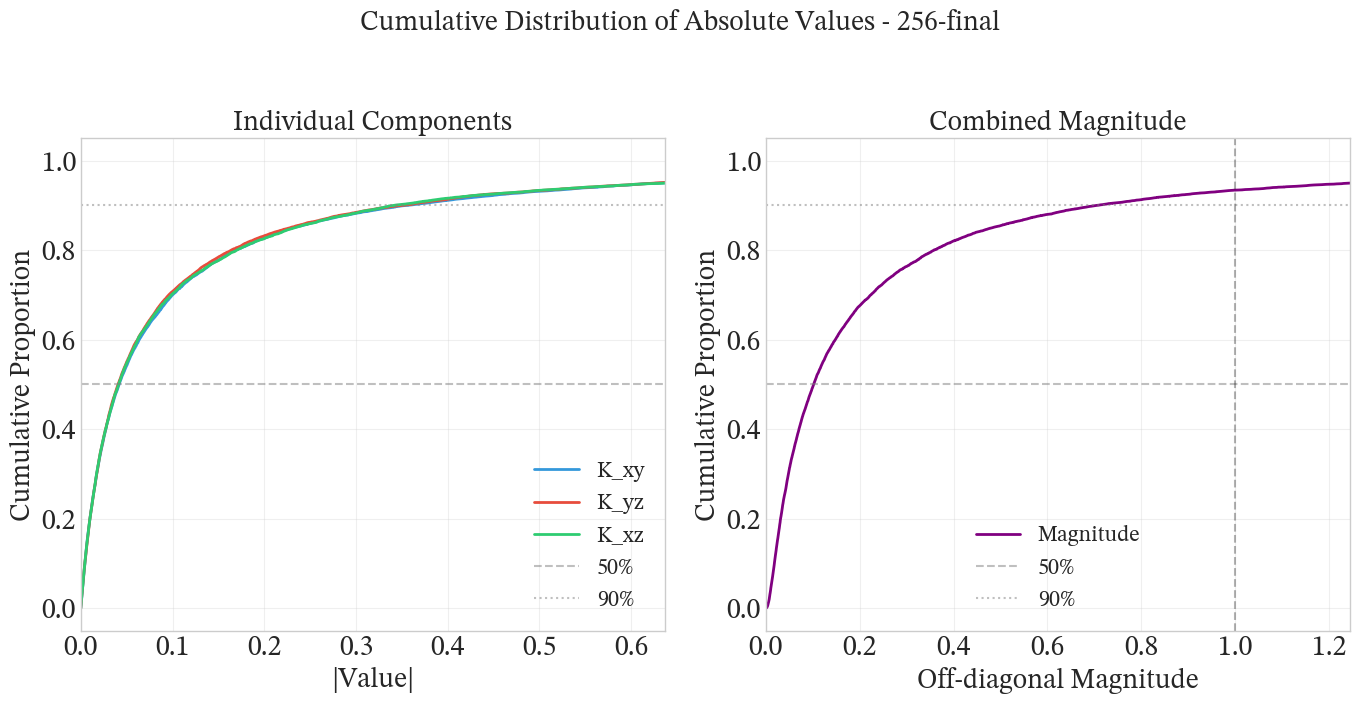

In [469]:
# Cumulative distribution plot for small values - 256-final
plot_small_value_distribution(df_256, '256-final')

In [470]:
# Categorize by order of magnitude - 256-final
mag_summary_256 = categorize_by_order_of_magnitude(df_256, '256-final')


ORDER OF MAGNITUDE DISTRIBUTION: 256-final

--- Counts by Order of Magnitude (|value|) ---



,K_xy,K_yz,K_xz,Magnitude
0,0,0,0,0
1e-14 to 1e-12,5,4,3,1
1e-12 to 1e-10,0,3,0,0
1e-10 to 1e-8,1,2,2,1
1e-8 to 1e-6,2,0,2,0
1e-6 to 1e-4,23,31,35,0
1e-4 to 1e-3,263,269,278,4
1e-3 to 1e-2,2293,2279,2270,499
1e-2 to 1e-1,6454,6550,6477,5883
1e-1 to 1,3516,3422,3472,5674



--- Percentages by Order of Magnitude ---



,K_xy %,K_yz %,K_xz %,Magnitude %
0,0.0%,0.0%,0.0%,0.0%
1e-14 to 1e-12,0.04%,0.03%,0.02%,0.01%
1e-12 to 1e-10,0.0%,0.02%,0.0%,0.0%
1e-10 to 1e-8,0.01%,0.02%,0.02%,0.01%
1e-8 to 1e-6,0.02%,0.0%,0.02%,0.0%
1e-6 to 1e-4,0.18%,0.24%,0.27%,0.0%
1e-4 to 1e-3,2.04%,2.08%,2.15%,0.03%
1e-3 to 1e-2,17.76%,17.65%,17.58%,3.86%
1e-2 to 1e-1,49.99%,50.73%,50.17%,45.57%
1e-1 to 1,27.23%,26.5%,26.89%,43.95%



--- Detailed Breakdown ---


K_xy:
  Exactly 0:                0 ( 0.00%)
  1e-14 to 1e-12:           5 ( 0.04%)
  1e-12 to 1e-10:           0 ( 0.00%)
  1e-10 to 1e-8:            1 ( 0.01%)
  1e-8 to 1e-6:             2 ( 0.02%)
  1e-6 to 1e-4:            23 ( 0.18%)
  1e-4 to 1e-3:           263 ( 2.04%)
  1e-3 to 1e-2:          2293 (17.76%)
  1e-2 to 1e-1:          6454 (49.99%)
  1e-1 to 1:             3516 (27.23%)
  1 to 10:                354 ( 2.74%)
  10 to 100:                0 ( 0.00%)
  > 100:                    0 ( 0.00%)

K_yz:
  Exactly 0:                0 ( 0.00%)
  1e-14 to 1e-12:           4 ( 0.03%)
  1e-12 to 1e-10:           3 ( 0.02%)
  1e-10 to 1e-8:            2 ( 0.02%)
  1e-8 to 1e-6:             0 ( 0.00%)
  1e-6 to 1e-4:            31 ( 0.24%)
  1e-4 to 1e-3:           269 ( 2.08%)
  1e-3 to 1e-2:          2279 (17.65%)
  1e-2 to 1e-1:          6550 (50.73%)
  1e-1 to 1:             3422 (26.50%)
  1 to 10:                347 ( 2.69%)
  10 to 100:         

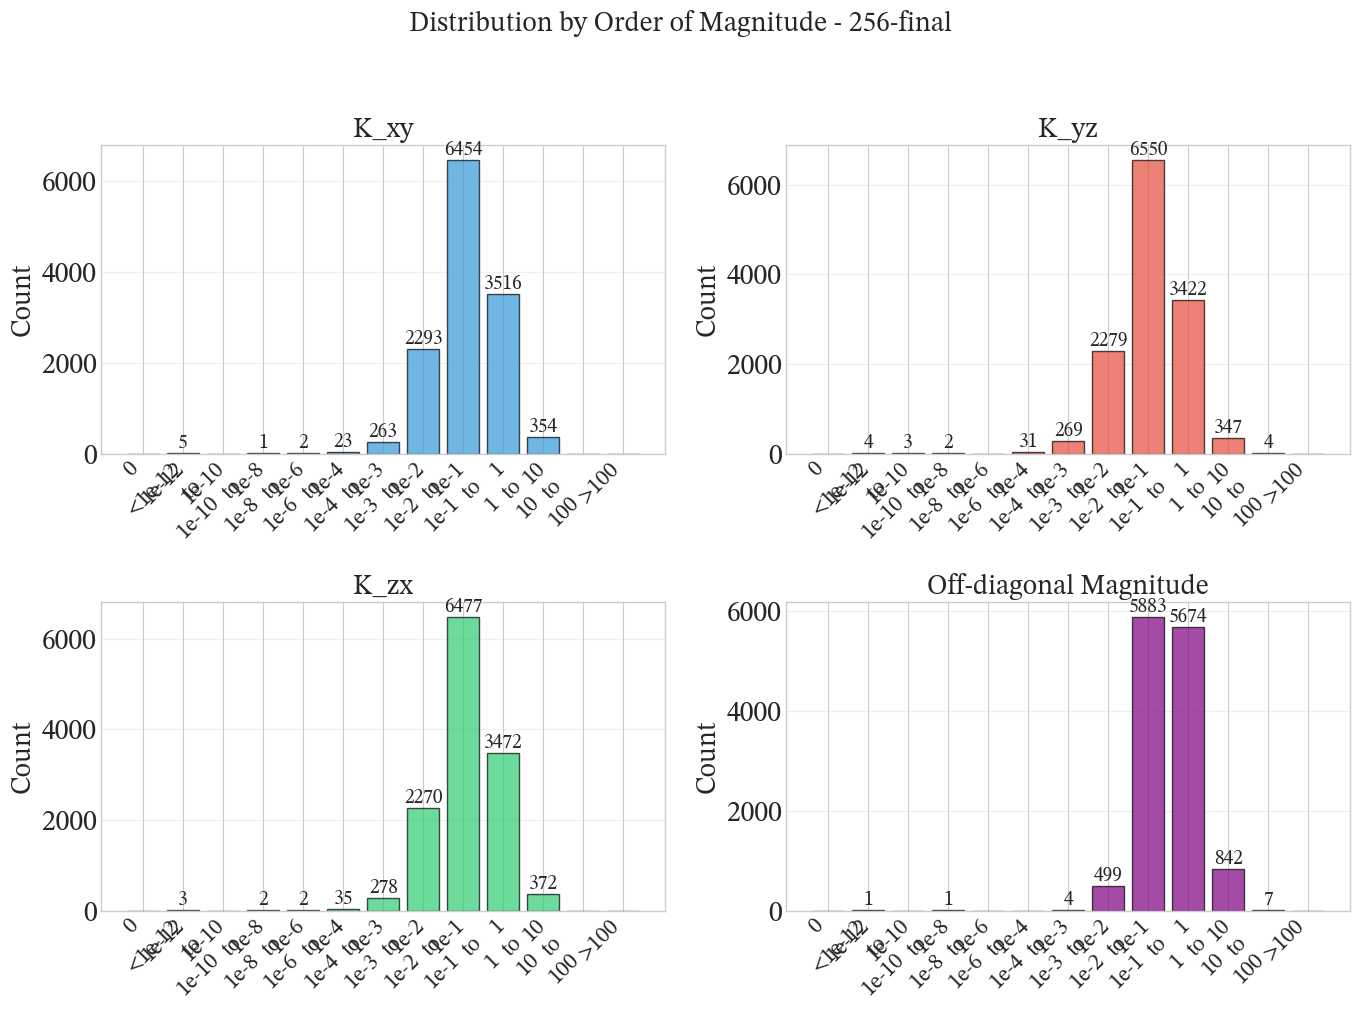

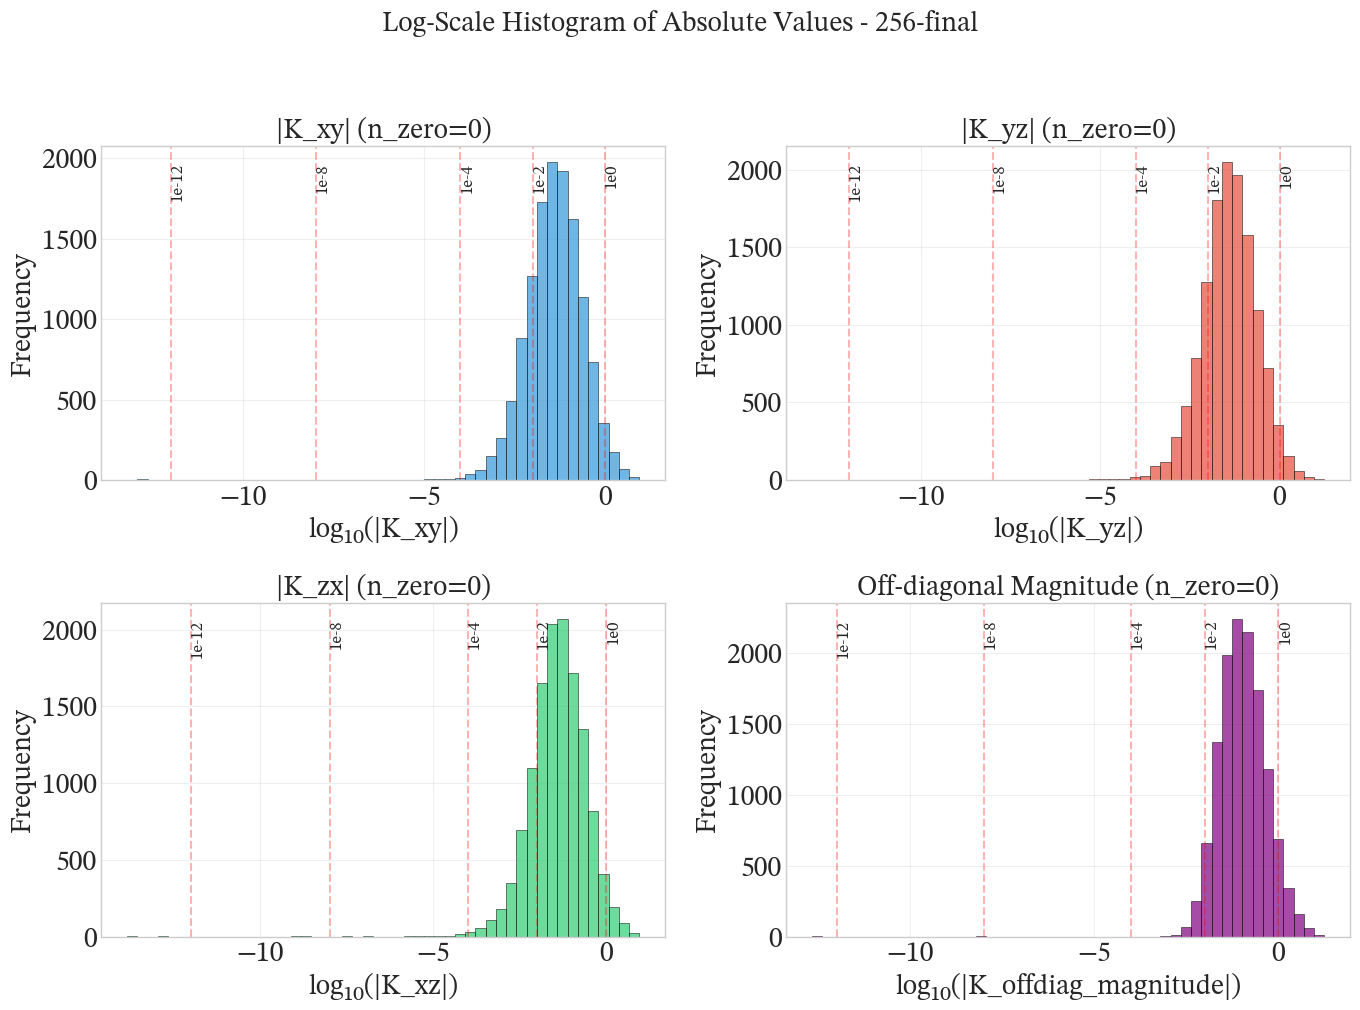

In [471]:
# Plot order of magnitude distribution - 256-final
plot_order_of_magnitude(df_256, '256-final')

# Log-scale histogram - 256-final
plot_log_histogram(df_256, '256-final')

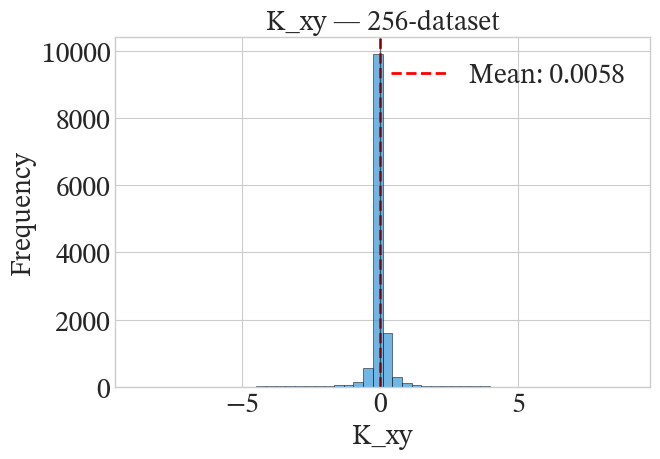

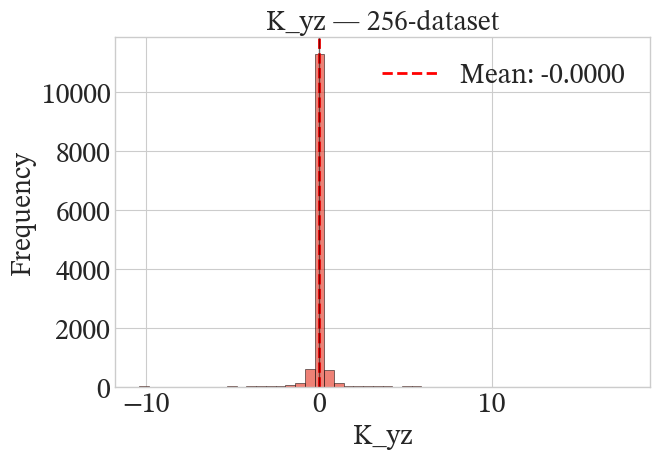

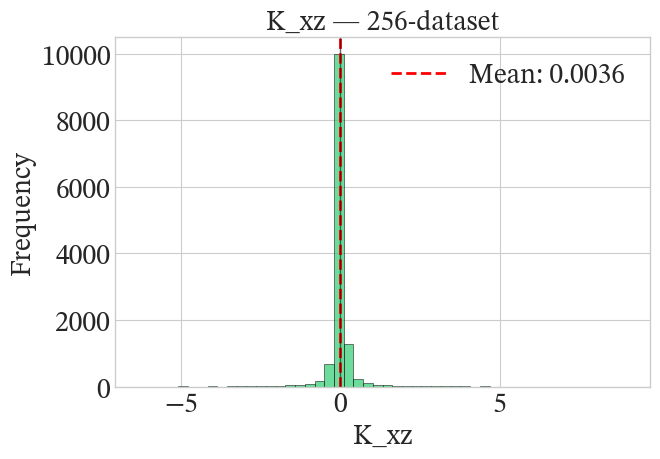

In [472]:
# Distribution plots for 256-final
plot_distributions(df_256, '256-dataset')

/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/1443607857.py:188: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([df[col].dropna() for col in target_cols],


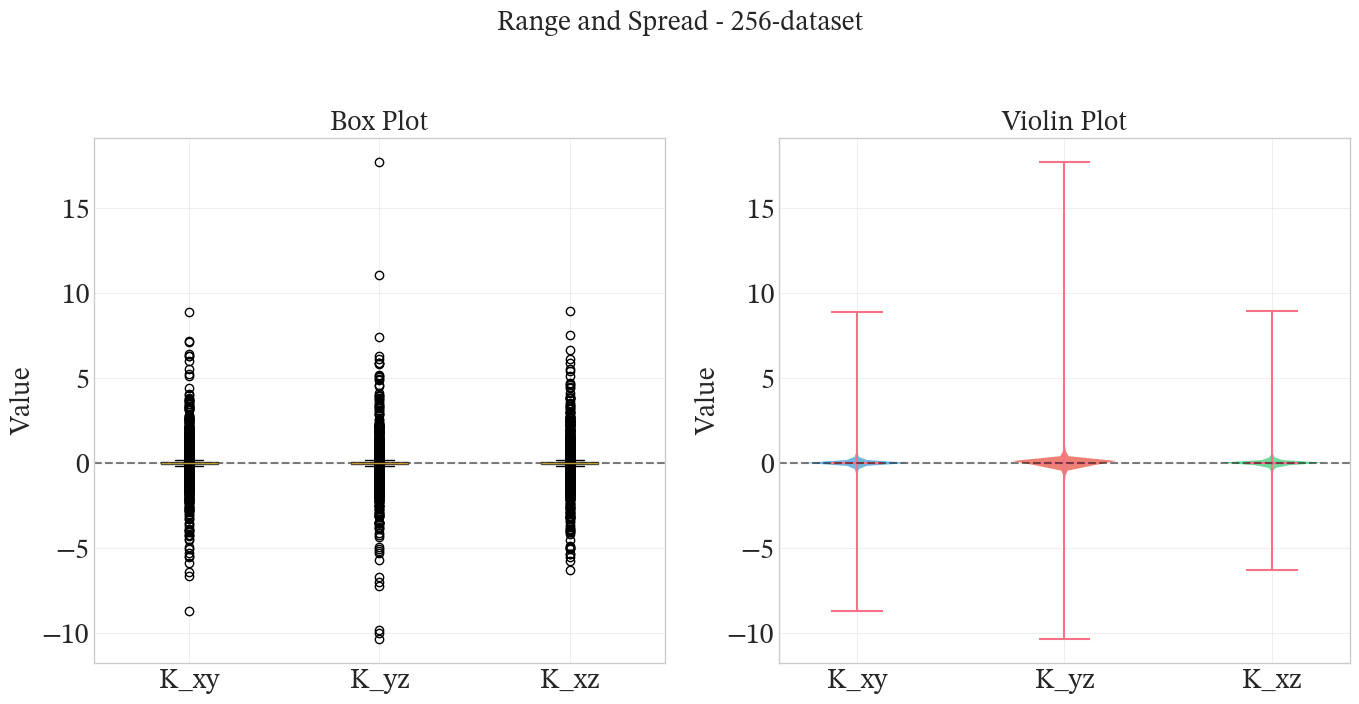

In [473]:
# Box and violin plots for 256-final
plot_boxplot_violin(df_256, '256-dataset')

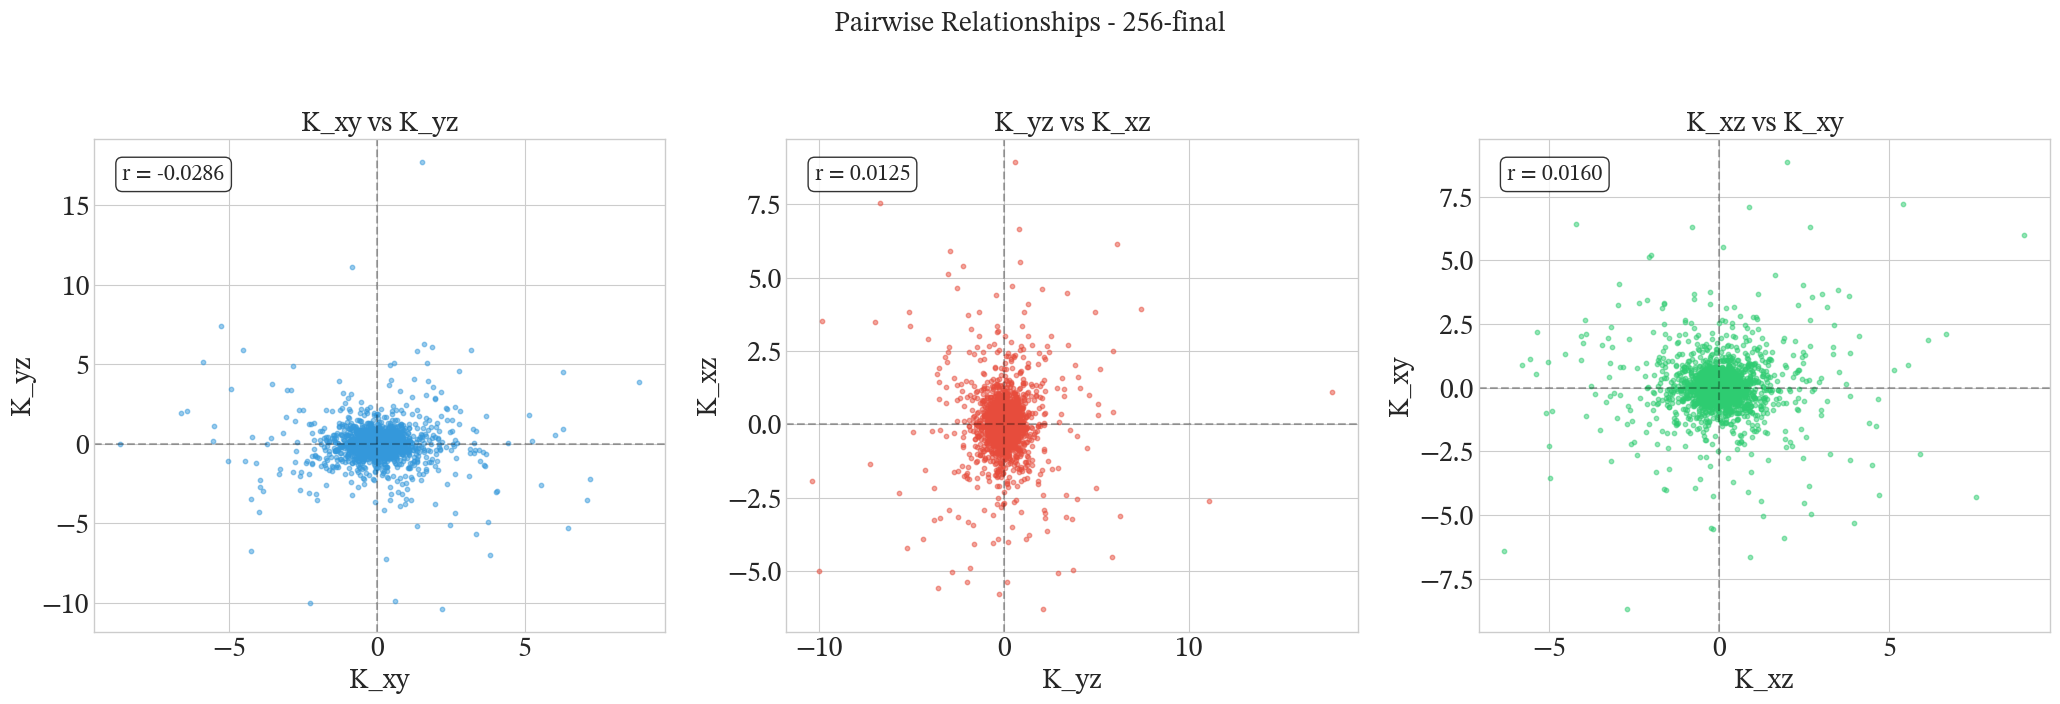

In [474]:
# Scatter relationships for 256-final
plot_scatter_relationships(df_256, '256-final')

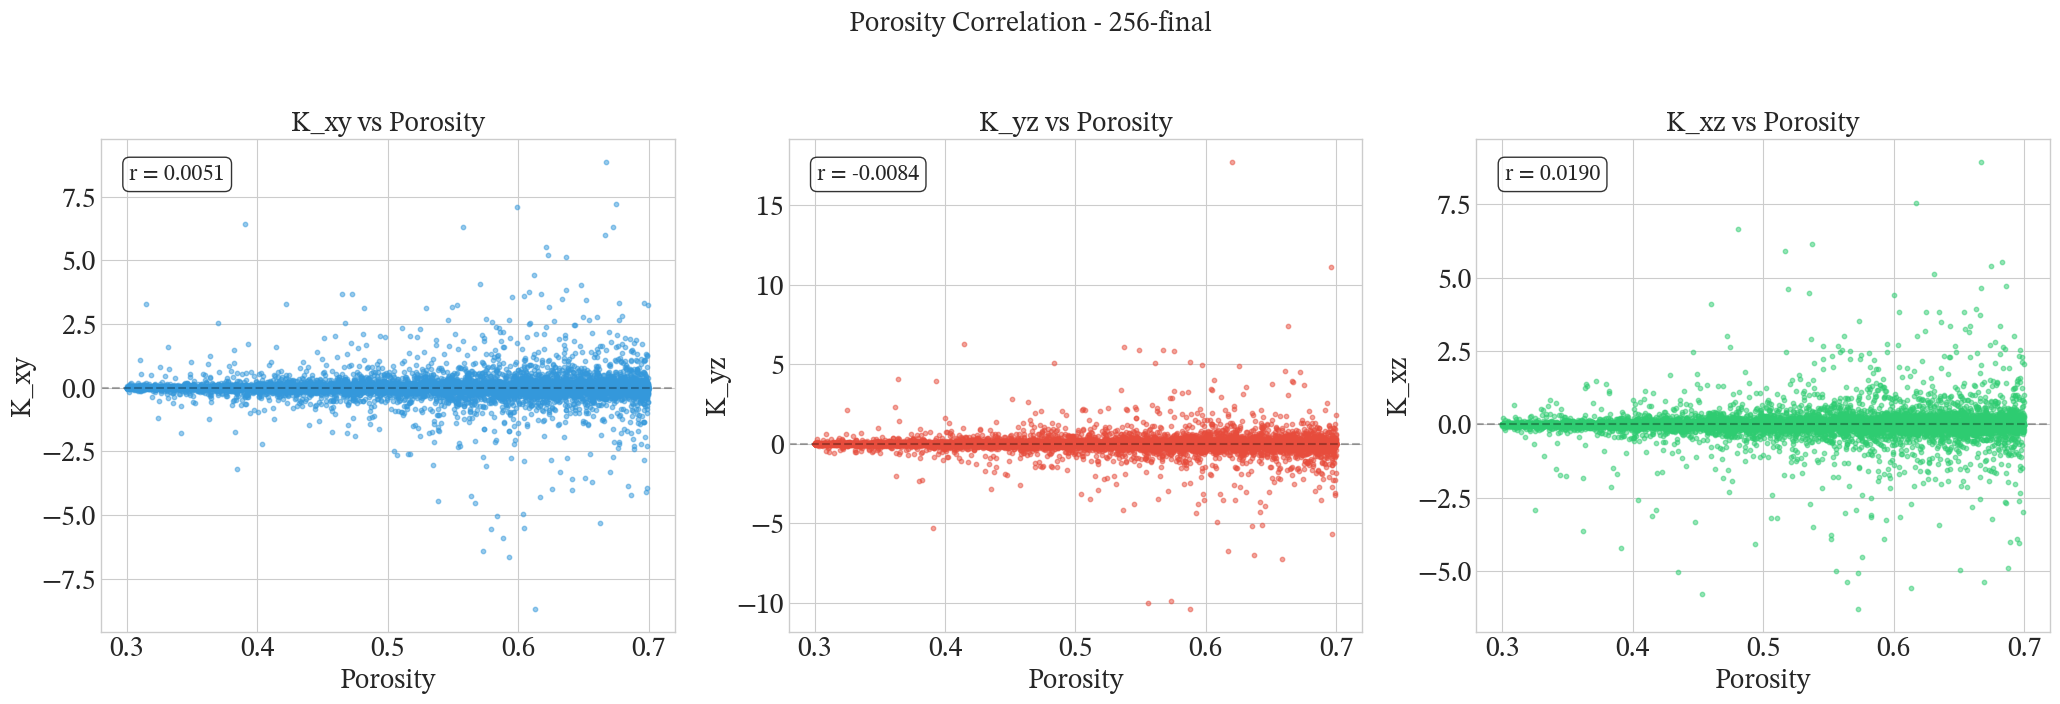

In [475]:
# Porosity correlation for 256-final
plot_porosity_correlation(df_256, '256-final')

In [476]:
# Get extreme samples for 256-final (15 low, 15 high)
low_256, high_256 = get_extreme_samples(df_256, '256-final', n_samples=15)


EXTREME SAMPLES: 256-final

--- 15 Samples with LOWEST Off-Diagonal Values (Most Isotropic) ---


,sample_name,porosity,K_xy,K_yz,K_xz,K_xx,K_yy,K_zz,K_offdiag_magnitude
1,eps_0.02_coeffs_0.396_0.586_0.908_72.95_132.53...,0.641953,1.919620e-13,9.341159e-14,1.840700e-14,0.106992,0.106992,0.106992,2.142754e-13
2,eps_0.02_coeffs_0.113_1.429_0.599_50.969_45.68...,0.499007,-9.484370e-09,1.153020e-13,-1.407949e-14,0.083167,1.605730,0.083167,9.484370e-09
3,eps_0.02_coeffs_0.394_-0.543_0.39_-15.881_81.8...,0.417609,-1.915277e-04,5.795647e-04,-1.624084e-04,0.519669,0.518341,0.515074,6.316285e-04
4,eps_0.02_coeffs_0.621_-0.487_0.26_-6.454_129.2...,0.300401,-5.449519e-04,-5.952713e-04,-3.581081e-05,0.228008,0.228259,0.228855,8.078384e-04
5,eps_0.02_coeffs_0.391_-0.63_0.809_32.18_125.77...,0.378604,1.001205e-04,-3.273716e-04,8.623243e-04,0.176587,0.193357,0.192276,9.277928e-04
6,eps_0.02_coeffs_0.782_0.479_0.836_-34.869_29.0...,0.449450,3.145871e-04,-6.702388e-04,6.206712e-04,2.798620,2.867759,2.900488,9.661355e-04
7,eps_0.02_coeffs_0.329_-0.538_0.46_-38.676_114....,0.689733,8.947931e-04,-4.164629e-04,-4.167053e-04,1.655266,1.650008,1.643929,1.071326e-03
8,eps_0.02_coeffs_0.465_-0.694_0.3_-39.898_52.46...,0.501387,-1.019621e-03,3.174397e-04,-3.915968e-04,0.975067,0.974617,0.972720,1.137428e-03
9,eps_0.02_coeffs_0.142_-0.545_0.256_-7.511_2.53...,0.632191,1.644583e-04,6.313809e-04,-9.765468e-04,1.674227,1.675202,1.674307,1.174450e-03
10,eps_0.02_coeffs_0.323_-0.01_0.844_-24.164_73.2...,0.683880,5.961718e-04,7.460828e-04,1.049547e-03,5.404383,5.380661,5.419830,1.419017e-03



--- 15 Samples with HIGHEST Off-Diagonal Values (Most Anisotropic) ---


,sample_name,porosity,K_xy,K_yz,K_xz,K_xx,K_yy,K_zz,K_offdiag_magnitude
1,eps_0.02_coeffs_0.178_0.855_0.549_86.579_117.2...,0.620247,1.520168,17.719805,1.114483,85.134543,75.577443,75.194065,17.819777
2,eps_0.02_coeffs_0.233_0.512_0.676_43_116.4_221...,0.696350,-0.862730,11.082538,-2.606741,60.727314,57.896723,50.946542,11.417620
3,eps_0.02_coeffs_0.166_0.804_0.588_61.612_116.9...,0.555565,-2.283916,-10.006467,-4.991706,16.171837,20.235580,17.040677,11.413273
4,eps_0.02_coeffs_0.11_0.651_0.733_73.24_104.878...,0.616912,-4.274461,-6.725426,7.541616,32.670891,12.145516,10.253914,10.971707
5,eps_0.02_coeffs_0.106_0.204_0.657_107.641_121....,0.666745,6.014121,0.559000,8.957796,41.084298,39.929914,41.465233,10.803900
6,eps_0.02_coeffs_0.305_0.888_0.454_103.045_149....,0.588075,2.194589,-10.388777,-1.924843,15.412370,20.453392,22.978310,10.791104
7,eps_0.02_coeffs_0.346_0.79_0.507_60.799_140.75...,0.573665,0.611399,-9.845742,3.509842,37.798429,39.917297,29.298851,10.470503
8,eps_0.02_coeffs_0.457_-0.511_0.732_85.441_142....,0.662896,-5.296215,7.406986,3.951115,33.963749,33.292609,32.487123,9.925958
9,eps_0.02_coeffs_0.177_0.074_0.768_34.683_123.2...,0.667189,8.882190,3.850417,2.008583,29.032410,30.345124,27.461563,9.887033
10,eps_0.02_coeffs_0.184_1.347_0.37_-8.593_77.979...,0.390876,6.448074,-5.278821,-4.198311,20.918079,9.438262,13.126227,9.331100


/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/1443607857.py:379: UserWarning: Glyph 8730 (\N{SQUARE ROOT}) missing from font(s) STIX Two Text.
  plt.tight_layout()
/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/1443607857.py:380: UserWarning: Glyph 8730 (\N{SQUARE ROOT}) missing from font(s) STIX Two Text.
  plt.savefig(f'{dataset_name}_extreme_distribution.png', dpi=300, bbox_inches='tight')
/Users/ahtishamkhan/PPP/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8730 (\N{SQUARE ROOT}) missing from font(s) STIX Two Text.
  fig.canvas.print_figure(bytes_io, **kw)


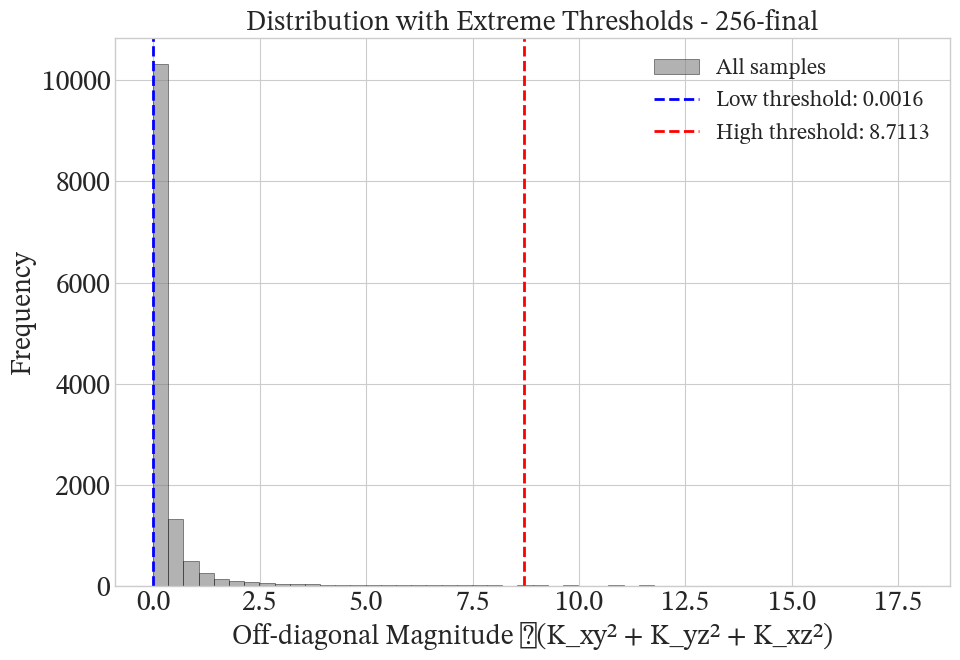

In [477]:
# Visualize extreme samples for 256-final
plot_extreme_samples_distribution(df_256, low_256, high_256, '256-final')

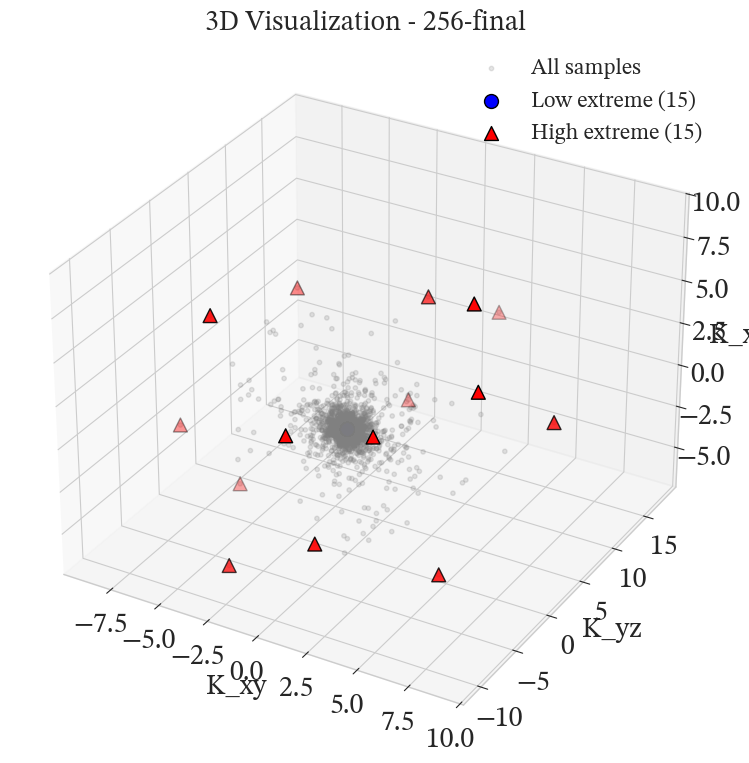

In [478]:
# 3D plot for 256-final
plot_3d_extremes(df_256, low_256, high_256, '256-final')

In [479]:
# Save extreme samples for 256-final
low_256.to_csv('256-final_extreme_low_samples.csv', index=True)
high_256.to_csv('256-final_extreme_high_samples.csv', index=True)
print("Saved: 256-final_extreme_low_samples.csv")
print("Saved: 256-final_extreme_high_samples.csv")

Saved: 256-final_extreme_low_samples.csv
Saved: 256-final_extreme_high_samples.csv


---
# Dataset 2: 128_final.csv
---

In [480]:
# Load 128_final.csv
# Note: This dataset uses K_zx instead of K_xz, so we rename for consistency
df_feature = pd.read_csv('128_final.csv')

# Rename K_zx to K_xz for consistent analysis
if 'K_zx' in df_feature.columns and 'K_xz' not in df_feature.columns:
    df_feature = df_feature.rename(columns={'K_zx': 'K_xz'})

df_feature = analyze_dataset(df_feature, '128-final')

ANALYSIS: 128-final
Total samples: 14129


In [481]:
# Statistics for 128-final
if 'df_feature' not in globals():
    df_feature = pd.read_csv('128_final.csv')
    # Rename K_zx to K_xz for consistent analysis
    if 'K_zx' in df_feature.columns and 'K_xz' not in df_feature.columns:
        df_feature = df_feature.rename(columns={'K_zx': 'K_xz'})

# Ensure off-diagonal magnitude exists
if 'K_offdiag_magnitude' not in df_feature.columns:
    df_feature = analyze_dataset(df_feature, '128-final')

stats_feature = print_statistics(df_feature, '128-final')

# Count small values for 128-final
small_vals_feature, mag_counts_feature = count_small_values(df_feature, '128-final')



STATISTICAL SUMMARY: 128-final


,K_xy,K_yz,K_xz
count,1.412900e+04,1.412900e+04,14129.000000
mean,-1.528776e-02,4.336276e-03,-0.012773
std,1.262825e+00,1.215097e+00,1.251294
min,-3.049784e+01,-2.347741e+01,-43.161249
25%,-3.818814e-02,-3.595260e-02,-0.038759
50%,-3.440680e-09,-5.120354e-07,-0.000236
75%,3.499235e-02,3.810111e-02,0.034266
max,3.137924e+01,2.613290e+01,23.800247
range,6.187708e+01,4.961031e+01,66.961496
IQR,7.318049e-02,7.405371e-02,0.073024



Additional Statistics:

  K_xy:
    Median: -0.000000
    Skewness: -2.7694
    Kurtosis: 164.4333
    % Positive: 49.91%
    % Negative: 50.09%

  K_yz:
    Median: -0.000001
    Skewness: 0.3868
    Kurtosis: 111.7174
    % Positive: 49.88%
    % Negative: 50.12%

  K_xz:
    Median: -0.000236
    Skewness: -3.8289
    Kurtosis: 220.6657
    % Positive: 49.39%
    % Negative: 50.61%

SMALL VALUE COUNTS: 128-final

--- Individual Component Counts (|value| < threshold) ---



,Threshold,K_xy Count,K_xy %,K_yz Count,K_yz %,K_xz Count,K_xz %
0,< 0.001,669,4.7%,640,4.5%,667,4.7%
1,< 0.01,3938,27.9%,3897,27.6%,3903,27.6%
2,< 0.1,9482,67.1%,9429,66.7%,9451,66.9%
3,< 0.5,12346,87.4%,12340,87.3%,12354,87.4%
4,< 1.0,13122,92.9%,13126,92.9%,13111,92.8%
5,< 2.0,13614,96.4%,13643,96.6%,13623,96.4%
6,< 5.0,13972,98.9%,13964,98.8%,13980,98.9%



--- Off-Diagonal Magnitude Counts (√(K_xy² + K_yz² + K_xz²) < threshold) ---



,Threshold,Count,Percentage
0,< 0.001,34,0.2%
1,< 0.01,1644,11.6%
2,< 0.1,7165,50.7%
3,< 0.5,10925,77.3%
4,< 1.0,12167,86.1%
5,< 2.0,13033,92.2%
6,< 5.0,13721,97.1%



--- Detailed Breakdown: Very Small Values ---


K_xy:
  |value| < 0.001:    669 (  4.7%)
  |value| < 0.01:    3938 ( 27.9%)
  |value| < 0.1:     9482 ( 67.1%)
  |value| < 1.0:    13122 ( 92.9%)

K_yz:
  |value| < 0.001:    640 (  4.5%)
  |value| < 0.01:    3897 ( 27.6%)
  |value| < 0.1:     9429 ( 66.7%)
  |value| < 1.0:    13126 ( 92.9%)

K_xz:
  |value| < 0.001:    667 (  4.7%)
  |value| < 0.01:    3903 ( 27.6%)
  |value| < 0.1:     9451 ( 66.9%)
  |value| < 1.0:    13111 ( 92.8%)

Off-diagonal Magnitude:
  magnitude < 0.001:     34 (  0.2%)
  magnitude < 0.01:    1644 ( 11.6%)
  magnitude < 0.1:     7165 ( 50.7%)
  magnitude < 1.0:    12167 ( 86.1%)


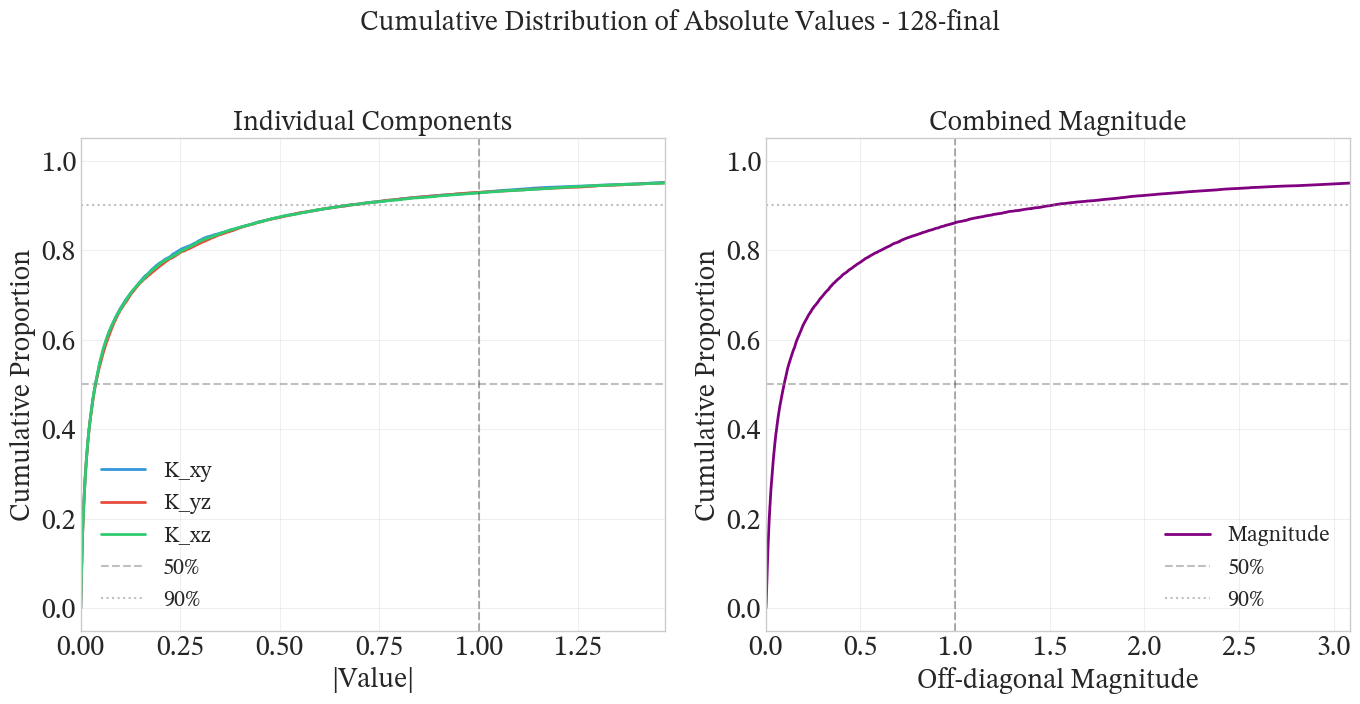

In [482]:
# Cumulative distribution plot for small values - 128-final
if 'df_feature' not in globals():
    df_feature = pd.read_csv('128_final.csv')
    # Rename K_zx to K_xz for consistent analysis
    if 'K_zx' in df_feature.columns and 'K_xz' not in df_feature.columns:
        df_feature = df_feature.rename(columns={'K_zx': 'K_xz'})

# Ensure off-diagonal magnitude exists
if 'K_offdiag_magnitude' not in df_feature.columns:
    df_feature = analyze_dataset(df_feature, '128-final')

plot_small_value_distribution(df_feature, '128-final')


In [483]:
# Categorize by order of magnitude - 128-final
mag_summary_feature = categorize_by_order_of_magnitude(df_feature, '128-final')


ORDER OF MAGNITUDE DISTRIBUTION: 128-final

--- Counts by Order of Magnitude (|value|) ---



,K_xy,K_yz,K_xz,Magnitude
0,0,0,0,0
1e-14 to 1e-12,10,5,5,0
1e-12 to 1e-10,9,9,8,1
1e-10 to 1e-8,14,8,11,3
1e-8 to 1e-6,6,11,9,1
1e-6 to 1e-4,56,46,67,1
1e-4 to 1e-3,574,561,567,28
1e-3 to 1e-2,3269,3257,3236,1610
1e-2 to 1e-1,5544,5532,5548,5521
1e-1 to 1,3640,3697,3660,5002



--- Percentages by Order of Magnitude ---



,K_xy %,K_yz %,K_xz %,Magnitude %
0,0.0%,0.0%,0.0%,0.0%
1e-14 to 1e-12,0.07%,0.04%,0.04%,0.0%
1e-12 to 1e-10,0.06%,0.06%,0.06%,0.01%
1e-10 to 1e-8,0.1%,0.06%,0.08%,0.02%
1e-8 to 1e-6,0.04%,0.08%,0.06%,0.01%
1e-6 to 1e-4,0.4%,0.33%,0.47%,0.01%
1e-4 to 1e-3,4.06%,3.97%,4.01%,0.2%
1e-3 to 1e-2,23.14%,23.05%,22.9%,11.4%
1e-2 to 1e-1,39.24%,39.15%,39.27%,39.08%
1e-1 to 1,25.76%,26.17%,25.9%,35.4%



--- Detailed Breakdown ---


K_xy:
  Exactly 0:                0 ( 0.00%)
  1e-14 to 1e-12:          10 ( 0.07%)
  1e-12 to 1e-10:           9 ( 0.06%)
  1e-10 to 1e-8:           14 ( 0.10%)
  1e-8 to 1e-6:             6 ( 0.04%)
  1e-6 to 1e-4:            56 ( 0.40%)
  1e-4 to 1e-3:           574 ( 4.06%)
  1e-3 to 1e-2:          3269 (23.14%)
  1e-2 to 1e-1:          5544 (39.24%)
  1e-1 to 1:             3640 (25.76%)
  1 to 10:                964 ( 6.82%)
  10 to 100:               43 ( 0.30%)
  > 100:                    0 ( 0.00%)

K_yz:
  Exactly 0:                0 ( 0.00%)
  1e-14 to 1e-12:           5 ( 0.04%)
  1e-12 to 1e-10:           9 ( 0.06%)
  1e-10 to 1e-8:            8 ( 0.06%)
  1e-8 to 1e-6:            11 ( 0.08%)
  1e-6 to 1e-4:            46 ( 0.33%)
  1e-4 to 1e-3:           561 ( 3.97%)
  1e-3 to 1e-2:          3257 (23.05%)
  1e-2 to 1e-1:          5532 (39.15%)
  1e-1 to 1:             3697 (26.17%)
  1 to 10:                959 ( 6.79%)
  10 to 100:         

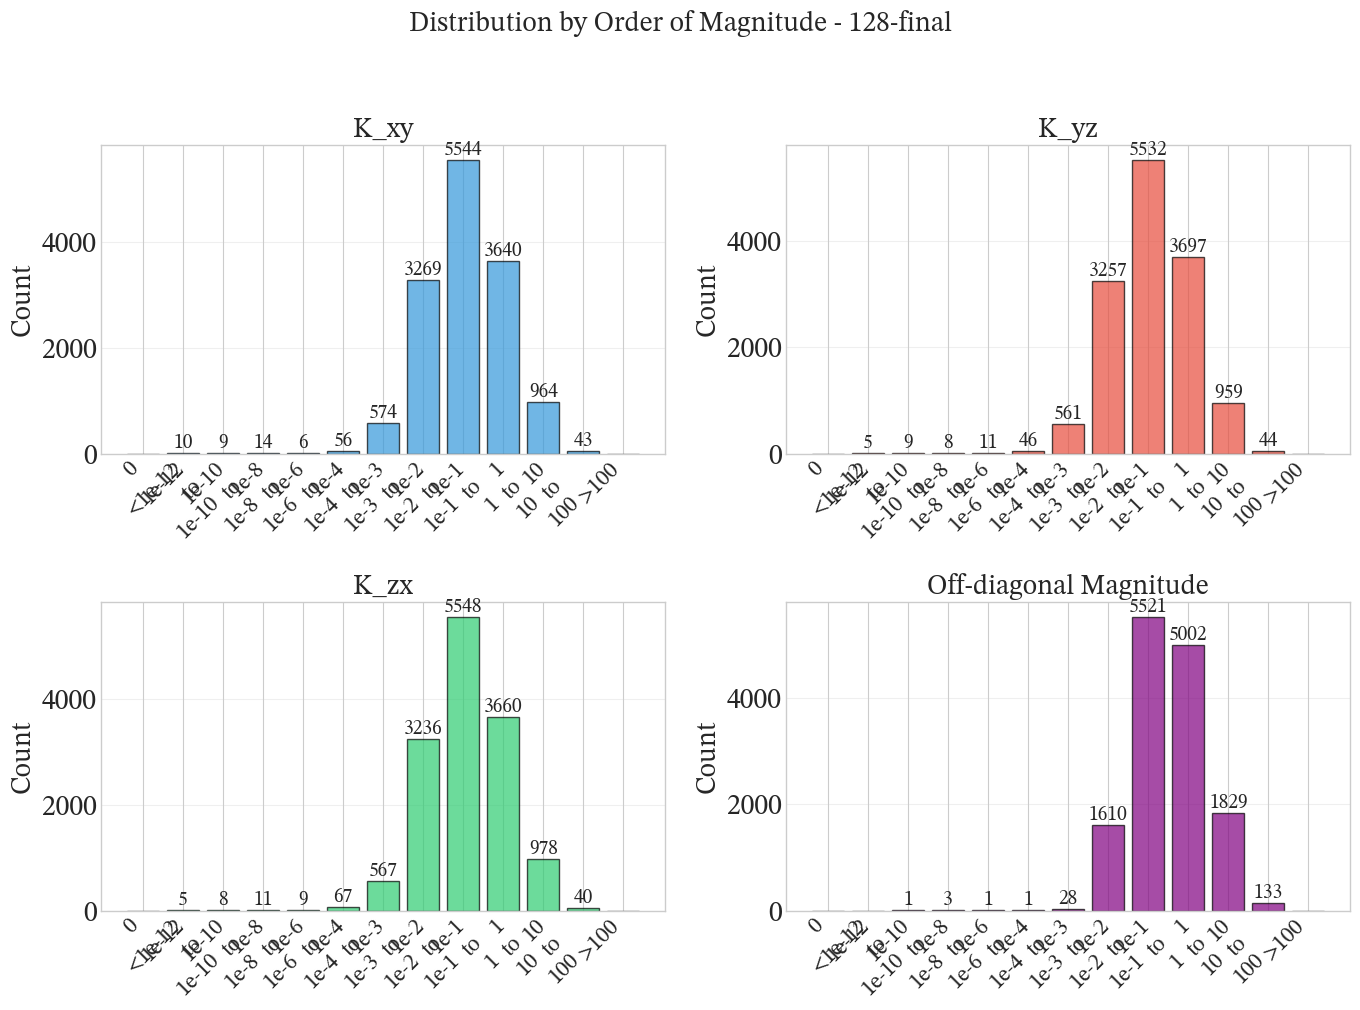

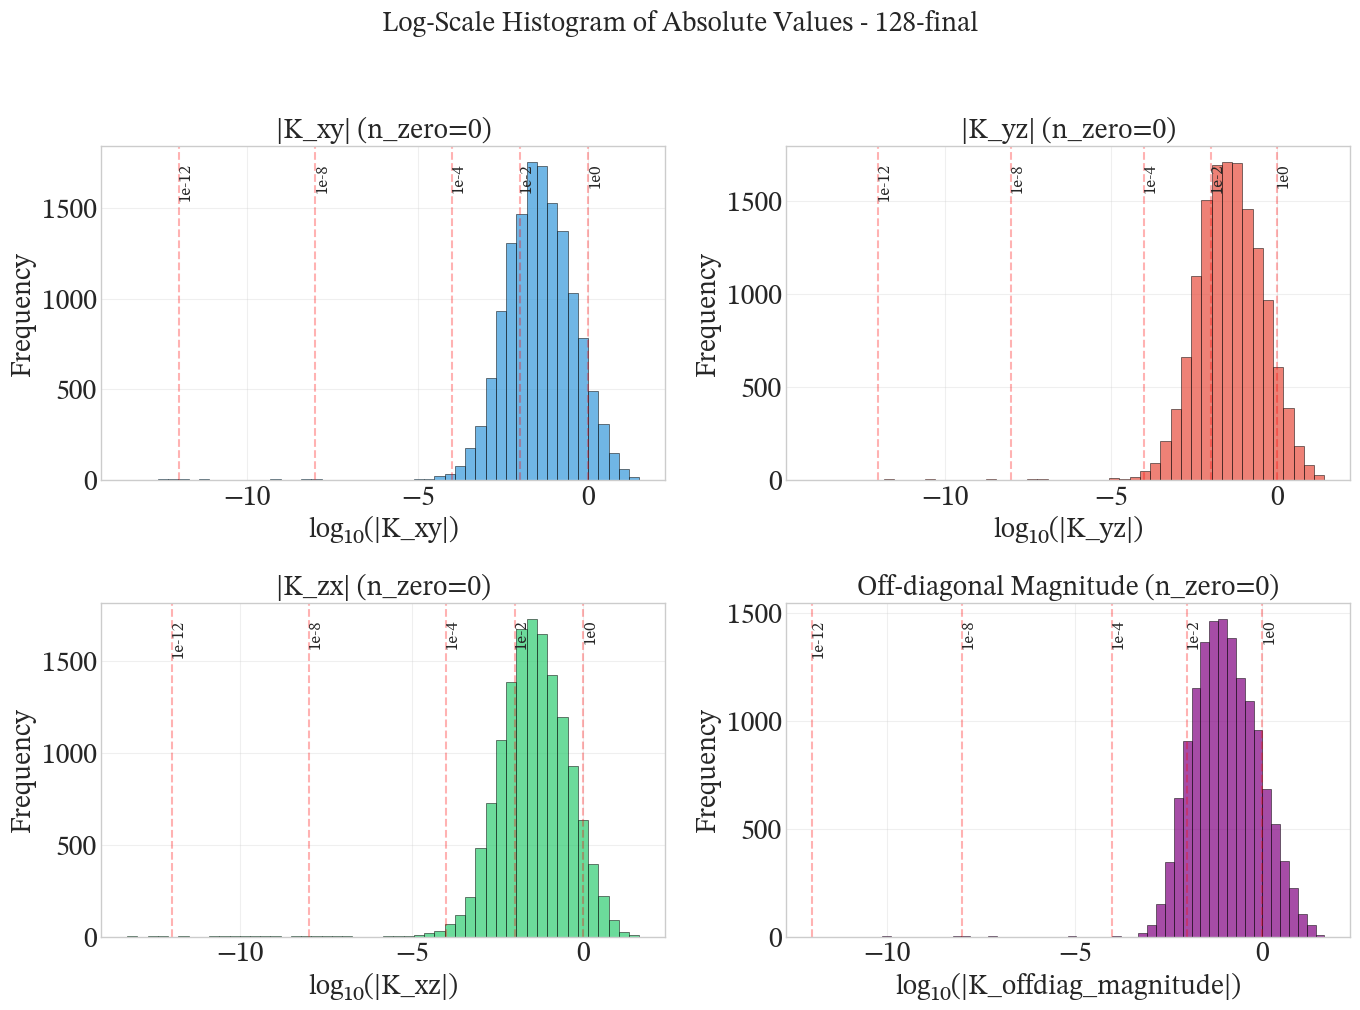

In [484]:
# Plot order of magnitude distribution - 128-final
plot_order_of_magnitude(df_feature, '128-final')

# Log-scale histogram - 128-final
plot_log_histogram(df_feature, '128-final')

In [485]:
# Statistics for 128-final
stats_feature = print_statistics(df_feature, '128-final')


STATISTICAL SUMMARY: 128-final


,K_xy,K_yz,K_xz
count,1.412900e+04,1.412900e+04,14129.000000
mean,-1.528776e-02,4.336276e-03,-0.012773
std,1.262825e+00,1.215097e+00,1.251294
min,-3.049784e+01,-2.347741e+01,-43.161249
25%,-3.818814e-02,-3.595260e-02,-0.038759
50%,-3.440680e-09,-5.120354e-07,-0.000236
75%,3.499235e-02,3.810111e-02,0.034266
max,3.137924e+01,2.613290e+01,23.800247
range,6.187708e+01,4.961031e+01,66.961496
IQR,7.318049e-02,7.405371e-02,0.073024



Additional Statistics:

  K_xy:
    Median: -0.000000
    Skewness: -2.7694
    Kurtosis: 164.4333
    % Positive: 49.91%
    % Negative: 50.09%

  K_yz:
    Median: -0.000001
    Skewness: 0.3868
    Kurtosis: 111.7174
    % Positive: 49.88%
    % Negative: 50.12%

  K_xz:
    Median: -0.000236
    Skewness: -3.8289
    Kurtosis: 220.6657
    % Positive: 49.39%
    % Negative: 50.61%


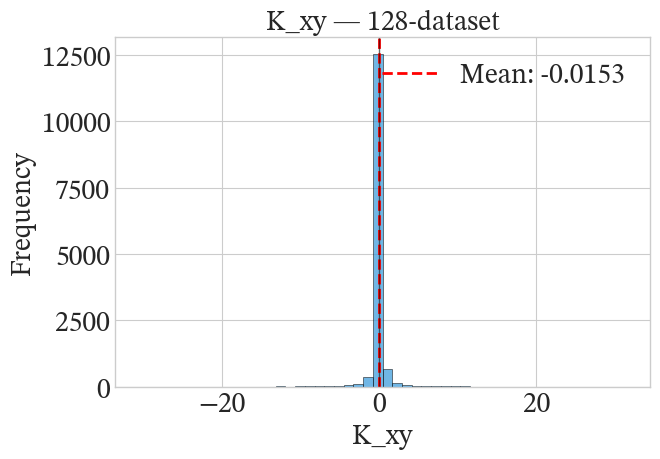

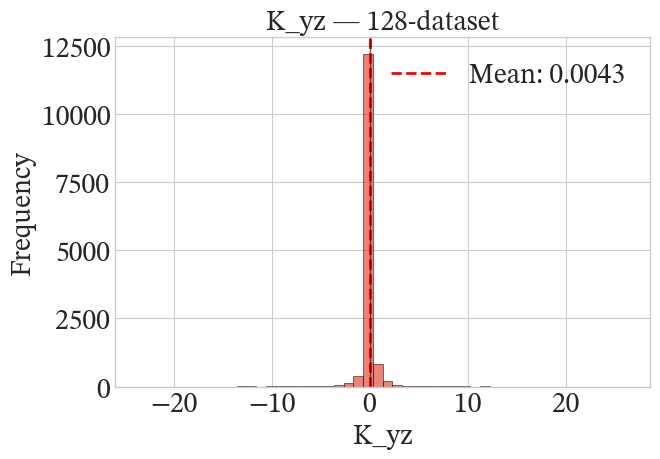

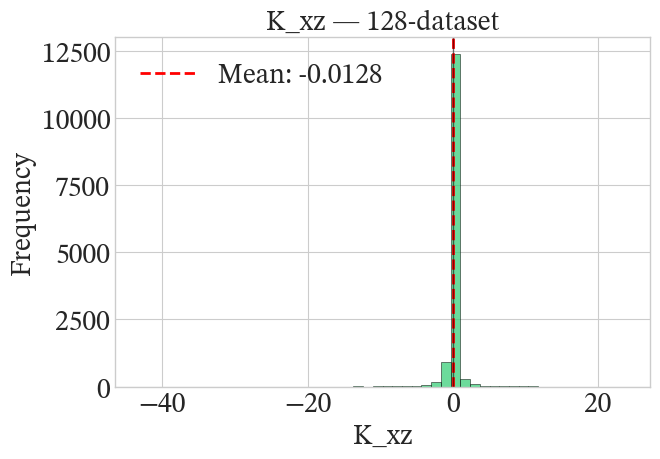

In [486]:
# Distribution plots for 128-final
plot_distributions(df_feature, '128-dataset')

/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/1443607857.py:188: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([df[col].dropna() for col in target_cols],


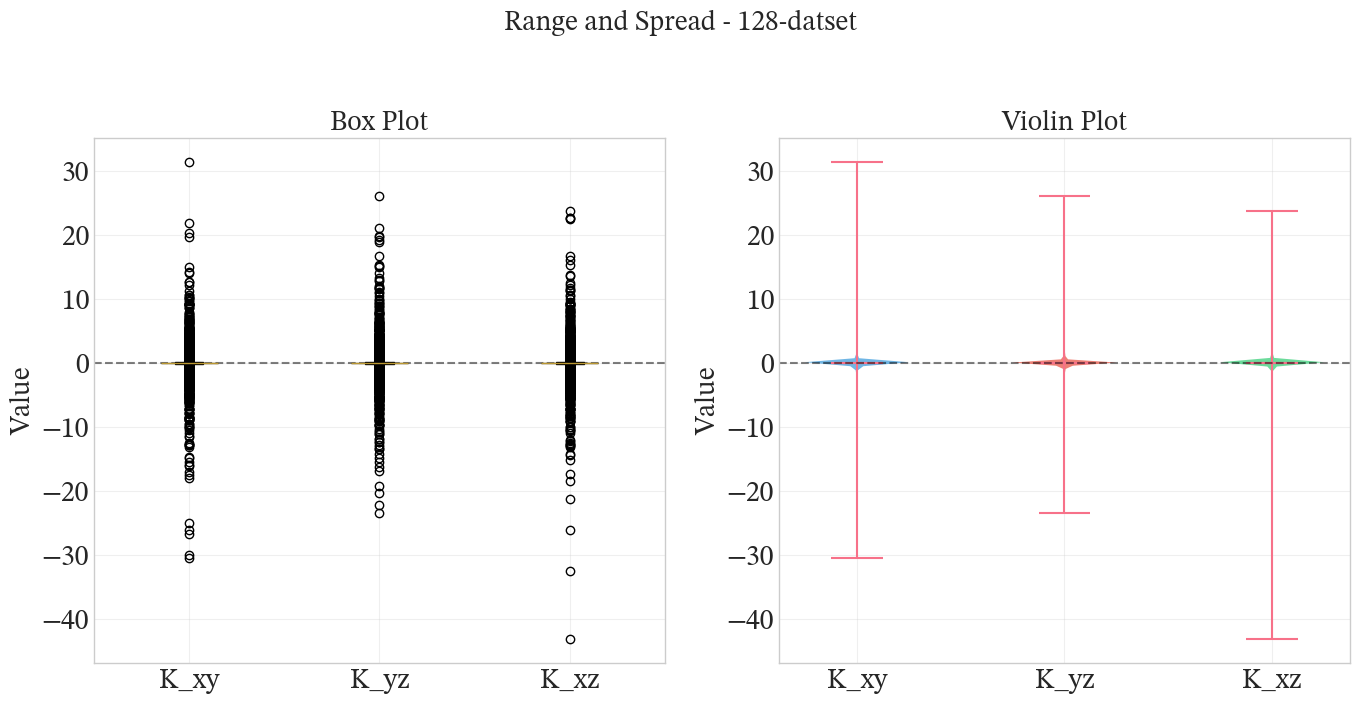

In [487]:
# Box and violin plots for 128-final
plot_boxplot_violin(df_feature, '128-datset')

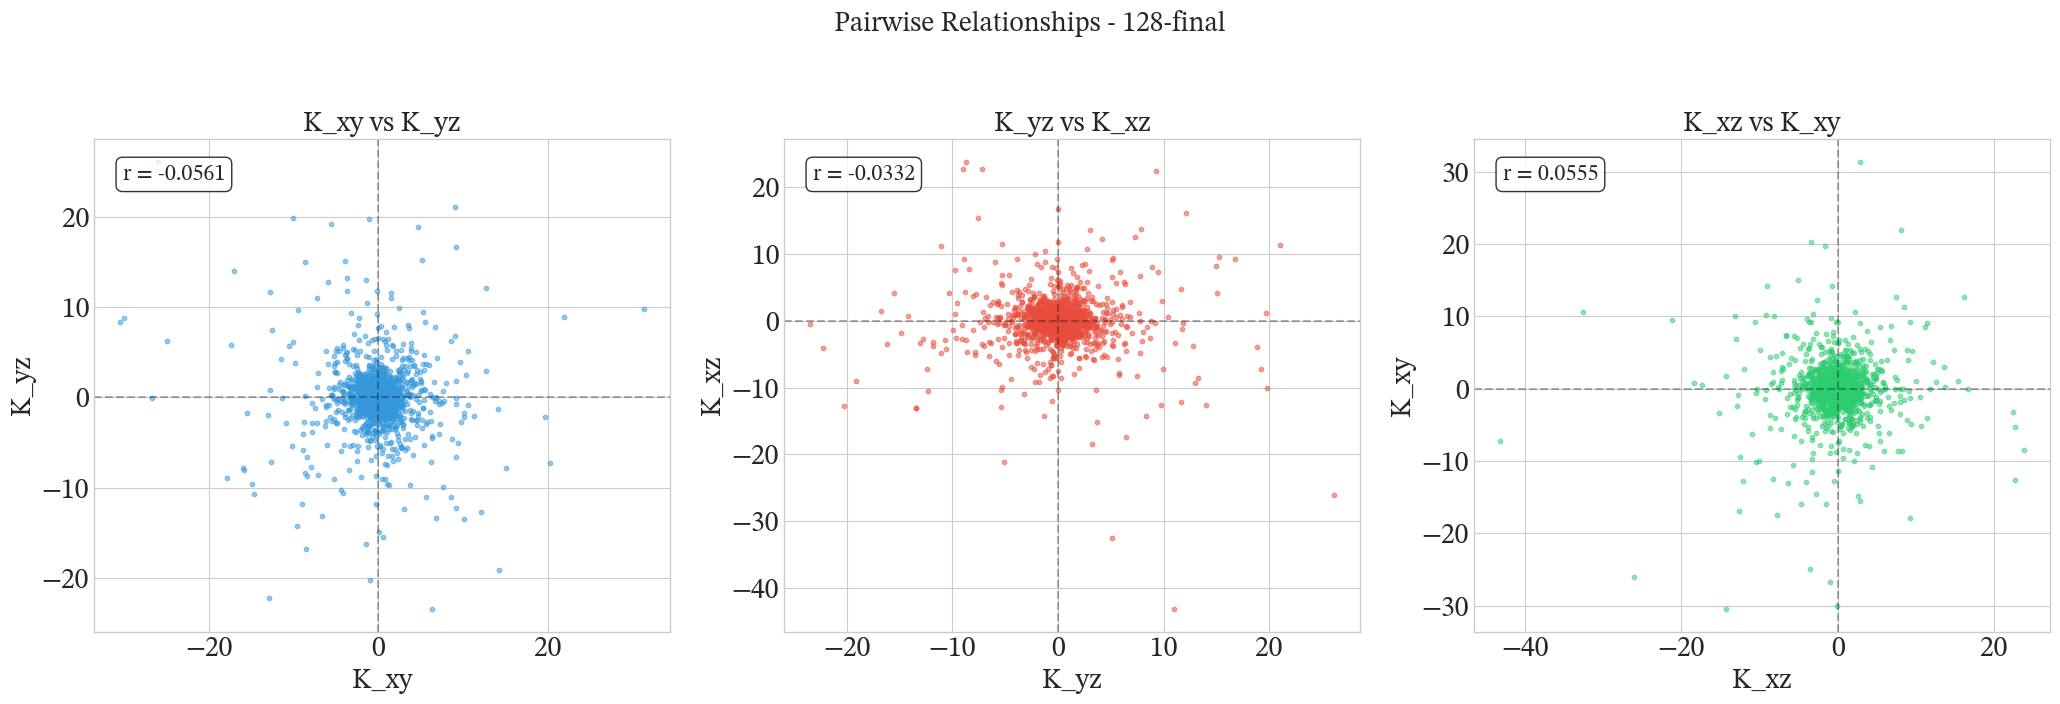

In [488]:
# Scatter relationships for 128-final
plot_scatter_relationships(df_feature, '128-final')

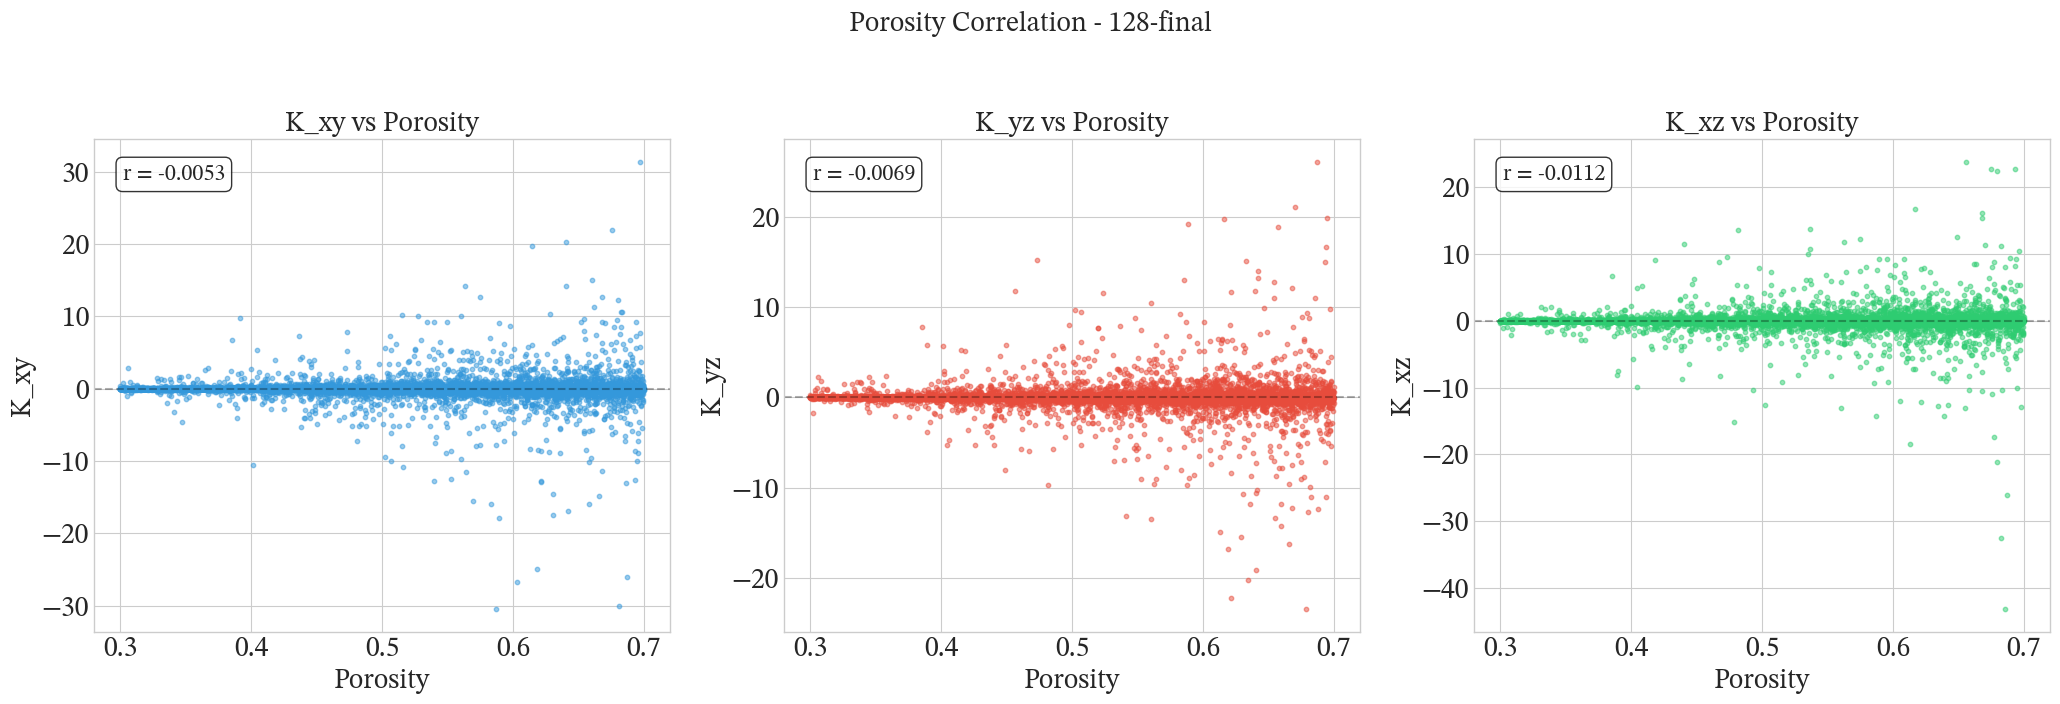

In [489]:
# Porosity correlation for 128-final
plot_porosity_correlation(df_feature, '128-final')

In [490]:
# Get extreme samples for 128-final (15 low, 15 high)
low_feature, high_feature = get_extreme_samples(df_feature, '128-final', n_samples=15)


EXTREME SAMPLES: 128-final

--- 15 Samples with LOWEST Off-Diagonal Values (Most Isotropic) ---


,sample_name,porosity,K_xy,K_yz,K_xz,K_xx,K_yy,K_zz,K_offdiag_magnitude
1,eps_0.02_coeffs_0.239_1.492_0.682_75.019_74.85...,0.598032,1.703644e-12,-4.486502e-11,-5.631843e-11,0.099670,0.099670,1.616150,7.202457e-11
2,eps_0.02_coeffs_0.535_1.029_0.47_119.914_143.8...,0.550259,1.445964e-13,-4.507966e-12,-1.050139e-10,0.091702,0.091703,0.720817,1.051107e-10
3,eps_0.02_coeffs_0.557_1.029_0.338_61.294_75.42...,0.608094,5.772346e-09,1.032920e-14,8.715032e-14,0.101347,6.421738,0.101347,5.772346e-09
4,eps_0.02_coeffs_0.386_0.413_0.861_6.601_96.663...,0.496974,-7.420129e-09,-6.037809e-09,-8.364189e-10,0.082827,0.082826,0.082826,9.602763e-09
5,eps_0.02_coeffs_0.665_1.433_0.915_55.863_140.3...,0.443915,5.758007e-13,-5.806553e-08,4.137851e-08,0.073982,0.073981,3.850315,7.130068e-08
6,eps_0.02_coeffs_0.69_1.275_0.279_49.991_75.999...,0.502361,2.993819e-12,9.581299e-06,3.067847e-10,0.083726,0.225273,0.697369,9.581299e-06
7,eps_0.02_coeffs_0.396_1.101_0.302_-19.674_43.3...,0.586571,-1.229042e-05,1.181826e-04,-3.275008e-05,0.928464,0.926136,0.908434,1.232507e-04
8,eps_0.02_coeffs_0.653_1.276_0.676_-4.992_112.6...,0.319559,3.078866e-04,-4.540995e-04,6.582926e-05,0.183842,0.178275,0.181905,5.525703e-04
9,eps_0.02_coeffs_0.626_-0.491_0.474_63.22_142.4...,0.335119,5.217210e-04,-2.081589e-04,2.539612e-05,0.112515,0.117382,0.114044,5.622881e-04
10,eps_0.02_coeffs_0.238_0.843_0.93_-38.225_25.91...,0.331744,-3.818687e-05,-5.760890e-04,7.946675e-05,0.302769,0.298276,0.303339,5.827965e-04



--- 15 Samples with HIGHEST Off-Diagonal Values (Most Anisotropic) ---


,sample_name,porosity,K_xy,K_yz,K_xz,K_xx,K_yy,K_zz,K_offdiag_magnitude
1,eps_0.02_coeffs_0.303_0.74_0.579_7.214_53.781_...,0.687282,-26.024050,26.132895,-26.073418,26.929448,27.241716,26.975753,45.166387
2,eps_0.02_coeffs_0.965_0.579_0.78_50.281_43.836...,0.685977,-7.244872,11.002423,-43.161249,82.515272,95.758177,82.468951,45.126875
3,eps_0.02_coeffs_0.691_0.412_0.377_-10.913_45.5...,0.587080,-30.497844,8.315709,-14.223638,43.663369,34.672603,41.407115,34.663834
4,eps_0.02_coeffs_0.523_-0.054_0.445_8.048_43.22...,0.682683,10.602343,5.106513,-32.527017,80.013901,90.015659,80.574622,34.590360
5,eps_0.02_coeffs_0.674_1.43_0.938_-4.03_36.014_...,0.696804,31.379239,9.814250,2.908020,59.967866,62.950643,70.004204,33.006556
6,eps_0.02_coeffs_0.869_1.364_0.464_8.187_51.952...,0.681264,-29.992295,8.841946,-0.107912,102.829242,185.317913,81.070327,31.268666
7,eps_0.02_coeffs_0.733_1.012_0.307_25.545_30.27...,0.693339,-12.649835,-7.151424,22.683038,32.357094,25.805339,34.680370,26.938475
8,eps_0.02_coeffs_0.964_0.881_0.657_52.391_61.48...,0.603095,-26.713527,-0.106067,-1.004805,35.977204,36.762971,17.052645,26.732628
9,eps_0.02_coeffs_0.423_1.16_0.363_3.978_8.939_4...,0.655581,-8.434485,-8.735972,23.800247,27.852274,46.890472,48.969562,26.719085
10,eps_0.02_coeffs_0.962_1.116_0.736_59.137_72.35...,0.621132,-12.855458,-22.223270,-4.105516,54.742844,49.748825,35.613084,25.999842


/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/1443607857.py:379: UserWarning: Glyph 8730 (\N{SQUARE ROOT}) missing from font(s) STIX Two Text.
  plt.tight_layout()
/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/1443607857.py:380: UserWarning: Glyph 8730 (\N{SQUARE ROOT}) missing from font(s) STIX Two Text.
  plt.savefig(f'{dataset_name}_extreme_distribution.png', dpi=300, bbox_inches='tight')
/Users/ahtishamkhan/PPP/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8730 (\N{SQUARE ROOT}) missing from font(s) STIX Two Text.
  fig.canvas.print_figure(bytes_io, **kw)


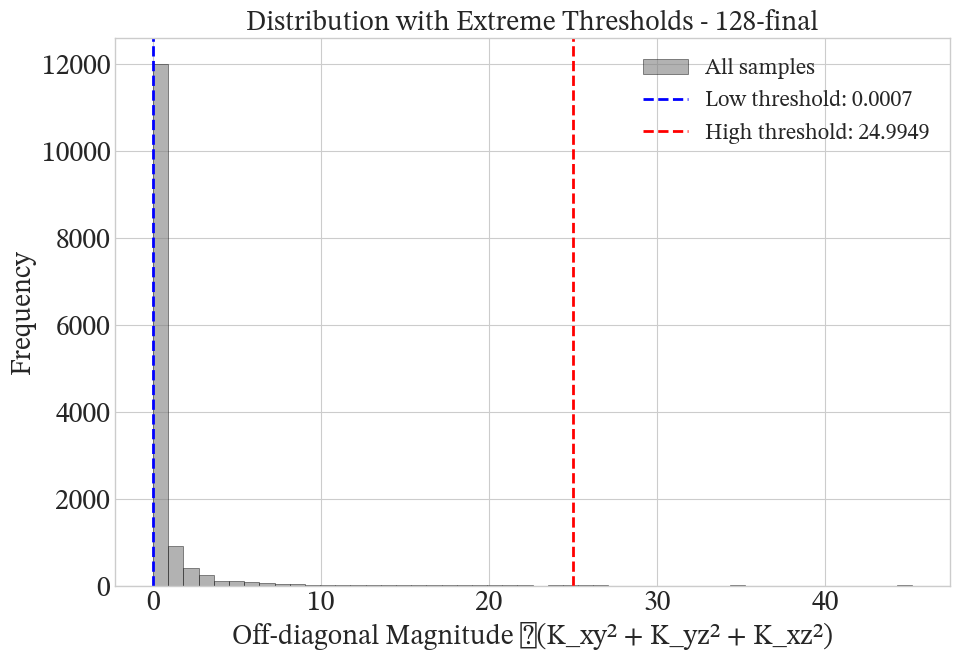

In [491]:
# Visualize extreme samples for 128-final
plot_extreme_samples_distribution(df_feature, low_feature, high_feature, '128-final')

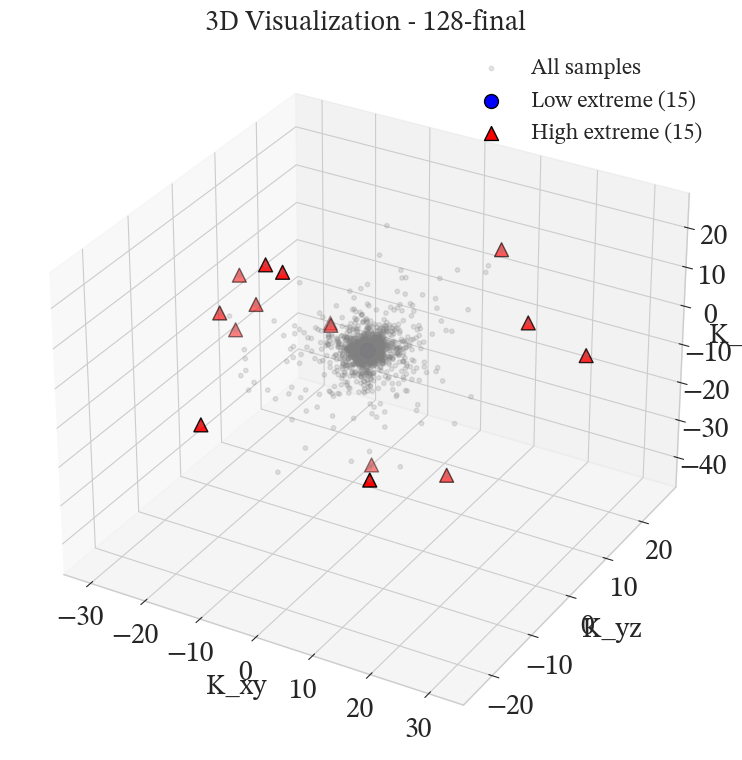

In [492]:
# 3D plot for 128-final
plot_3d_extremes(df_feature, low_feature, high_feature, '128-final')

In [493]:
# Save extreme samples for 128-final
low_feature.to_csv('128-final_extreme_low_samples.csv', index=True)
high_feature.to_csv('128-final_extreme_high_samples.csv', index=True)
print("Saved: 128-final_extreme_low_samples.csv")
print("Saved: 128-final_extreme_high_samples.csv")

Saved: 128-final_extreme_low_samples.csv
Saved: 128-final_extreme_high_samples.csv


---
# Porosity Distribution: Trend Histograms
---

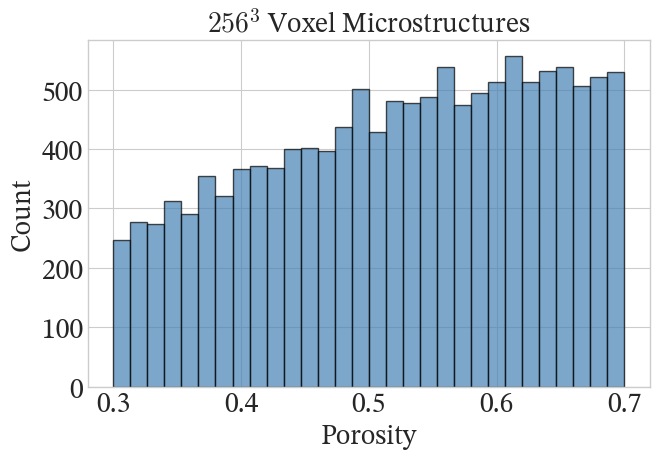

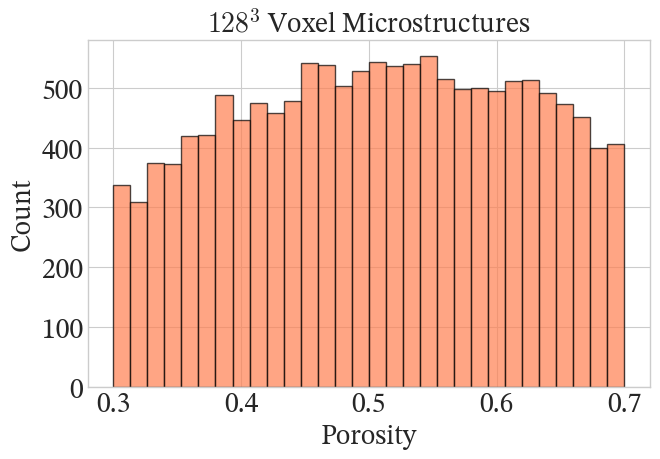

In [494]:
# Porosity trend histogram - 256^3 voxel microstructures
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df_256['porosity'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('$256^3$ Voxel Microstructures', fontsize=20)
ax.set_xlabel('Porosity', fontsize=20)
ax.set_ylabel('Count', fontsize=20)
plt.tight_layout()
plt.savefig('porosity_histogram_256.png', dpi=300, bbox_inches='tight')
plt.show()

# Porosity trend histogram - 128^3 voxel microstructures
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df_feature['porosity'], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax.set_title('$128^3$ Voxel Microstructures', fontsize=20)
ax.set_xlabel('Porosity', fontsize=20)
ax.set_ylabel('Count', fontsize=20)
plt.tight_layout()
plt.savefig('porosity_histogram_128.png', dpi=300, bbox_inches='tight')
plt.show()


---
# Comparison Between Datasets
---

In [495]:
# Side-by-side comparison of statistics
print("=" * 80)
print("COMPARISON: 256-final vs 128-final")
print("=" * 80)

comparison_metrics = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'IQR']

for col in target_cols:
    print(f"\n--- {col} ---")
    comp_df = pd.DataFrame({
        'Metric': comparison_metrics,
        '256-final': [stats_256.loc[m, col] if m in stats_256.index else None for m in comparison_metrics],
        '128-final': [stats_feature.loc[m, col] if m in stats_feature.index else None for m in comparison_metrics]
    })
    display(comp_df)

COMPARISON: 256-final vs 128-final

--- K_xy ---


,Metric,256-final,128-final
0,count,12911.000000,1.412900e+04
1,mean,0.005796,-1.528776e-02
2,std,0.447704,1.262825e+00
3,min,-8.701155,-3.049784e+01
4,25%,-0.039977,-3.818814e-02
5,50%,0.000873,-3.440680e-09
6,75%,0.043335,3.499235e-02
7,max,8.882190,3.137924e+01
8,range,17.583345,6.187708e+01
9,IQR,0.083312,7.318049e-02



--- K_yz ---


,Metric,256-final,128-final
0,count,12911.000000,1.412900e+04
1,mean,-0.000010,4.336276e-03
2,std,0.489782,1.215097e+00
3,min,-10.388777,-2.347741e+01
4,25%,-0.039937,-3.595260e-02
5,50%,0.000273,-5.120354e-07
6,75%,0.041348,3.810111e-02
7,max,17.719805,2.613290e+01
8,range,28.108582,4.961031e+01
9,IQR,0.081285,7.405371e-02



--- K_xz ---


,Metric,256-final,128-final
0,count,12911.000000,14129.000000
1,mean,0.003603,-0.012773
2,std,0.445017,1.251294
3,min,-6.300306,-43.161249
4,25%,-0.040816,-0.038759
5,50%,0.000328,-0.000236
6,75%,0.041705,0.034266
7,max,8.957796,23.800247
8,range,15.258102,66.961496
9,IQR,0.082520,0.073024


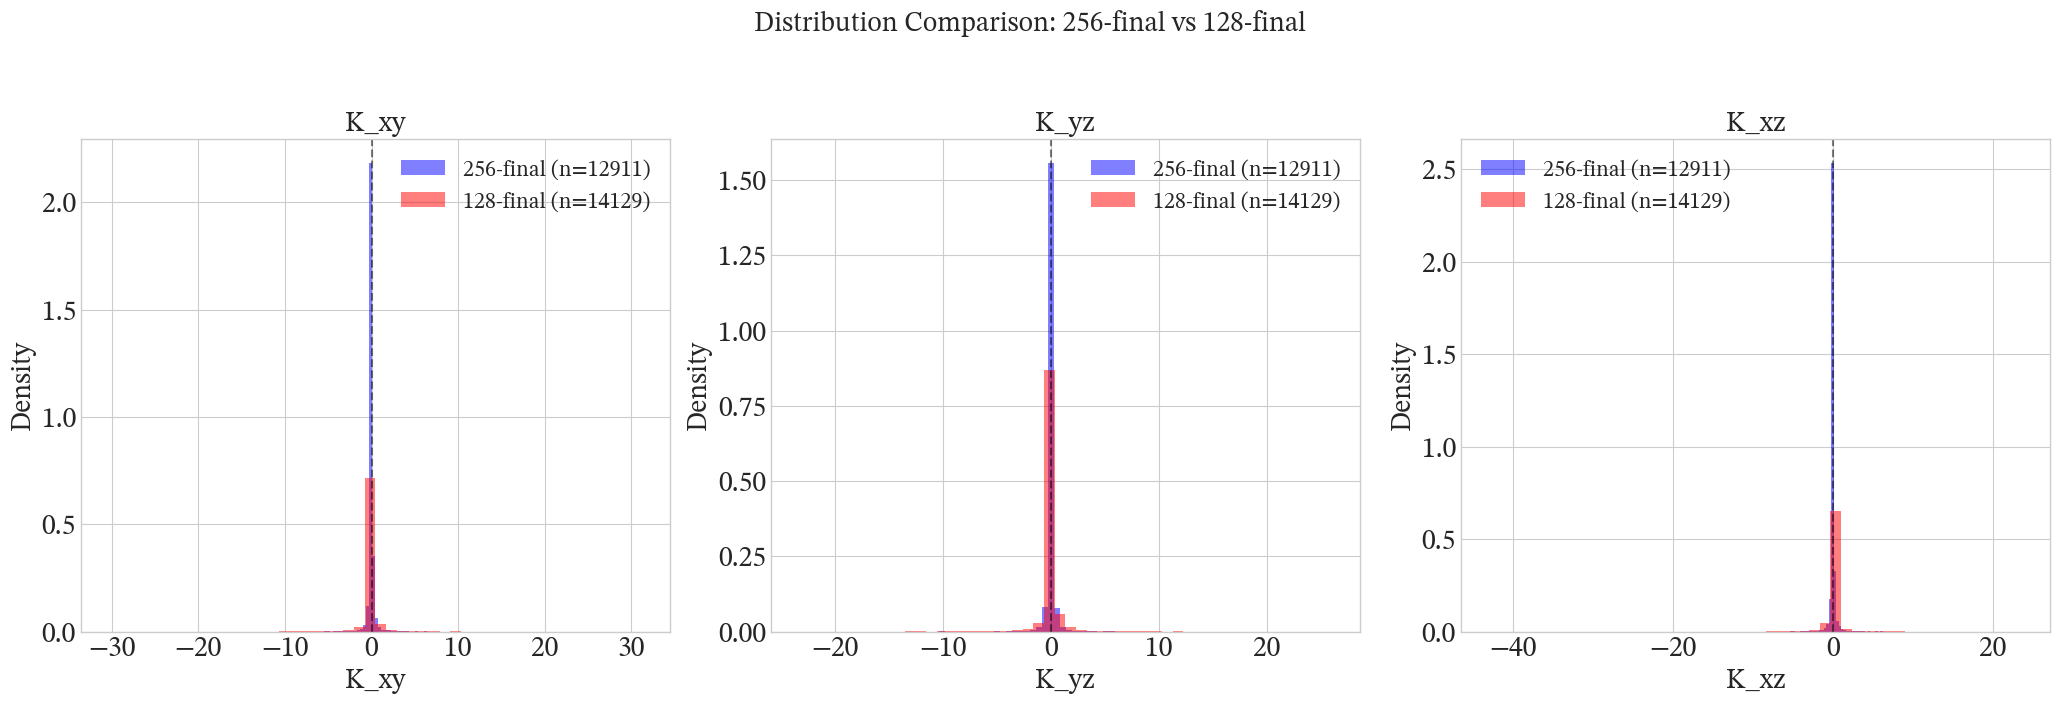

In [496]:
# Overlaid distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Distribution Comparison: 256-final vs 128-final', fontsize=20, y=1.02)

for i, col in enumerate(target_cols):
    ax = axes[i]
    
    ax.hist(df_256[col].dropna(), bins=50, alpha=0.5, color='blue', 
            label=f'256-final (n={len(df_256)})', density=True)
    ax.hist(df_feature[col].dropna(), bins=50, alpha=0.5, color='red', 
            label=f'128-final (n={len(df_feature)})', density=True)
    
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel(col, fontsize=20)
    ax.set_ylabel('Density', fontsize=20)
    ax.set_title(f'{col}', fontsize=20)
    ax.legend(fontsize=16)

plt.tight_layout()
plt.savefig('comparison_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/2690600432.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_256[col].dropna(), df_feature[col].dropna()],
/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/2690600432.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_256[col].dropna(), df_feature[col].dropna()],
/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/2690600432.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_256[col].dropna(), df_feature[col].dropna()],


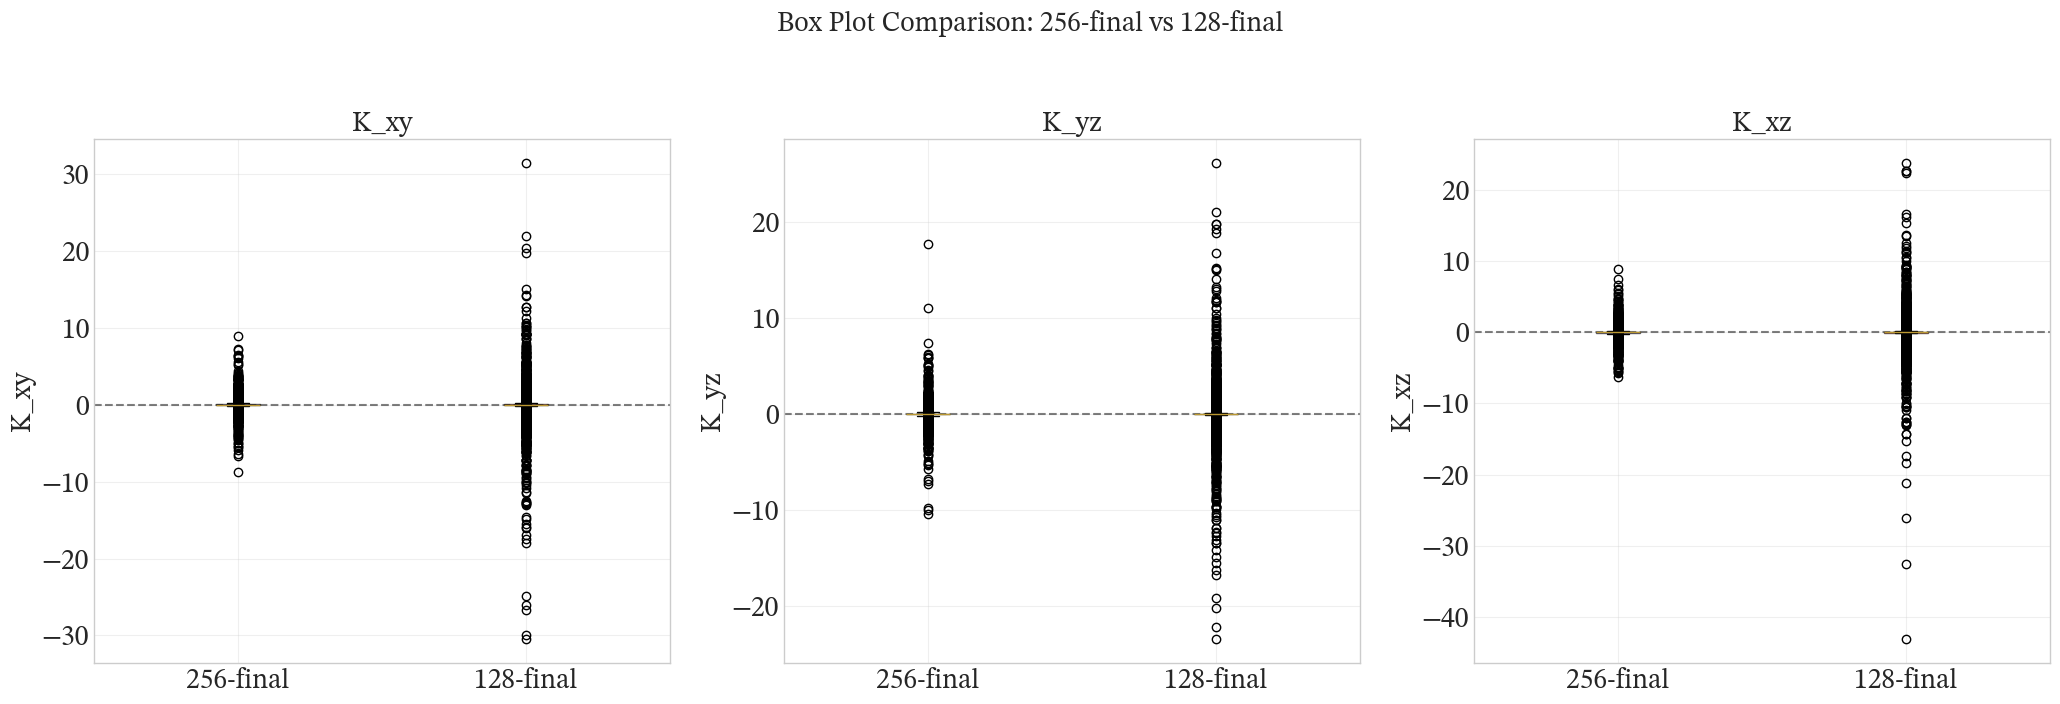

In [497]:
# Box plot comparison
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Box Plot Comparison: 256-final vs 128-final', fontsize=20, y=1.02)

for i, col in enumerate(target_cols):
    ax = axes[i]
    
    bp = ax.boxplot([df_256[col].dropna(), df_feature[col].dropna()],
                    labels=['256-final', '128-final'], patch_artist=True)
    
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('red')
    bp['boxes'][1].set_alpha(0.6)
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_ylabel(col, fontsize=20)
    ax.set_title(f'{col}', fontsize=20)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


---
# Permeability Tensor Diagonal Analysis
Analysis of the diagonal components ($K_{xx}$, $K_{yy}$, $K_{zz}$) — the principal permeabilities.

In [498]:
# Diagonal elements: value range counts
diag_cols = ['K_xx', 'K_yy', 'K_zz']

ranges = [(0, 0.5), (0.5, 1), (1, 2), (2, 5), (5, 10), (10, 20), (20, 50), (50, 100), (100, np.inf)]
range_labels = ['0–0.5', '0.5–1', '1–2', '2–5', '5–10', '10–20', '20–50', '50–100', '>100']

for df, label in [(df_256, '256-final'), (df_feature, '128-final')]:
    print(f'\n{"="*60}')
    print(f'DIAGONAL VALUE COUNTS: {label}  (n={len(df)})')
    print(f'{"="*60}')
    
    rows = []
    for lo, hi in ranges:
        row = {}
        for col in diag_cols:
            count = ((df[col] >= lo) & (df[col] < hi)).sum()
            pct = count / len(df) * 100
            row[col] = f'{count}  ({pct:.1f}%)'
        rows.append(row)
    
    summary = pd.DataFrame(rows, index=range_labels)
    summary.index.name = 'Range'
    display(summary)



DIAGONAL VALUE COUNTS: 256-final  (n=12911)


,K_xx,K_yy,K_zz
Range,,,
0–0.5,355 (2.7%),348 (2.7%),353 (2.7%)
0.5–1,1178 (9.1%),1170 (9.1%),1173 (9.1%)
1–2,2114 (16.4%),2141 (16.6%),2153 (16.7%)
2–5,4116 (31.9%),4084 (31.6%),4056 (31.4%)
5–10,3322 (25.7%),3361 (26.0%),3363 (26.0%)
10–20,1571 (12.2%),1549 (12.0%),1567 (12.1%)
20–50,248 (1.9%),249 (1.9%),237 (1.8%)
50–100,7 (0.1%),9 (0.1%),9 (0.1%)
>100,0 (0.0%),0 (0.0%),0 (0.0%)



DIAGONAL VALUE COUNTS: 128-final  (n=14129)


,K_xx,K_yy,K_zz
Range,,,
0–0.5,3853 (27.3%),3853 (27.3%),3866 (27.4%)
0.5–1,3163 (22.4%),3172 (22.5%),3195 (22.6%)
1–2,3021 (21.4%),3035 (21.5%),3019 (21.4%)
2–5,2431 (17.2%),2441 (17.3%),2408 (17.0%)
5–10,855 (6.1%),842 (6.0%),877 (6.2%)
10–20,496 (3.5%),484 (3.4%),443 (3.1%)
20–50,266 (1.9%),258 (1.8%),272 (1.9%)
50–100,40 (0.3%),42 (0.3%),48 (0.3%)
>100,4 (0.0%),2 (0.0%),1 (0.0%)


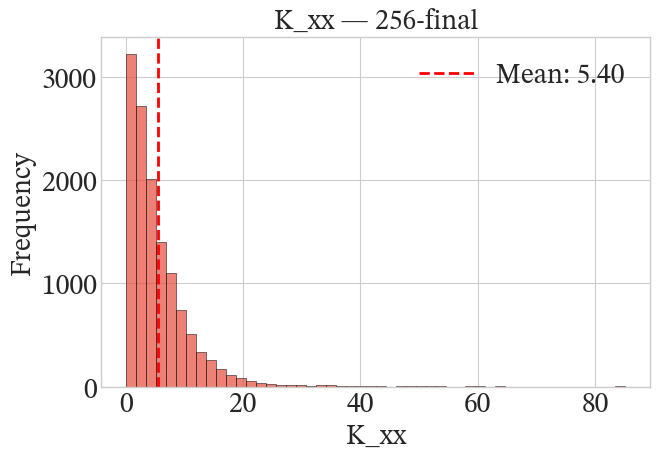

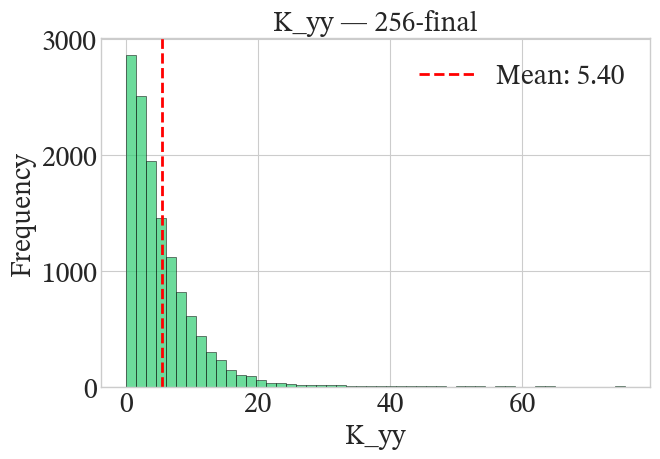

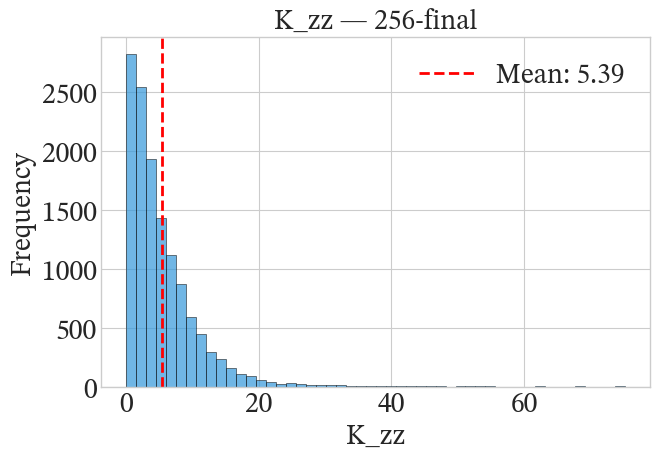

In [499]:
# Diagonal distribution histograms - 256-final
diag_colors = ['#e74c3c', '#2ecc71', '#3498db']
for i, col in enumerate(diag_cols):
    fig, ax = plt.subplots(figsize=(7, 5))
    data = df_256[col].dropna()
    ax.hist(data, bins=50, color=diag_colors[i], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
    ax.set_xlabel(col, fontsize=20)
    ax.set_ylabel('Frequency', fontsize=20)
    ax.set_title(f'{col} — 256-final', fontsize=20)
    ax.legend(fontsize=20)
    ax.tick_params(axis='both', labelsize=20)
    plt.tight_layout()
    plt.savefig(f'256-final_{col}_diag_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


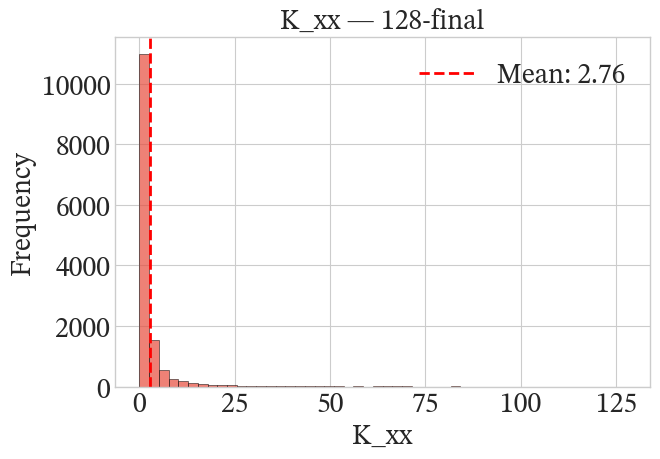

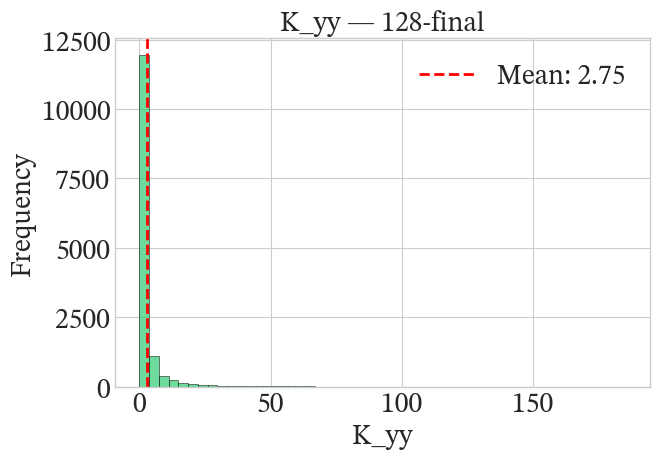

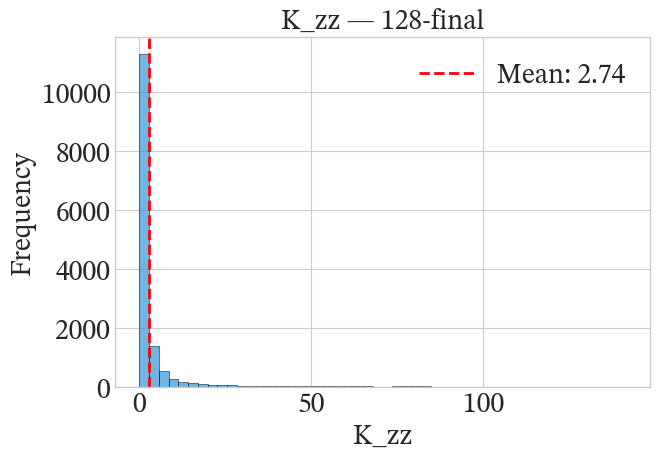

In [500]:
# Diagonal distribution histograms - 128-final
for i, col in enumerate(diag_cols):
    fig, ax = plt.subplots(figsize=(7, 5))
    data = df_feature[col].dropna()
    ax.hist(data, bins=50, color=diag_colors[i], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
    ax.set_xlabel(col, fontsize=20)
    ax.set_ylabel('Frequency', fontsize=20)
    ax.set_title(f'{col} — 128-final', fontsize=20)
    ax.legend(fontsize=20)
    ax.tick_params(axis='both', labelsize=20)
    plt.tight_layout()
    plt.savefig(f'128-final_{col}_diag_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/1443607857.py:236: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([df[col].dropna() for col in diag_cols],


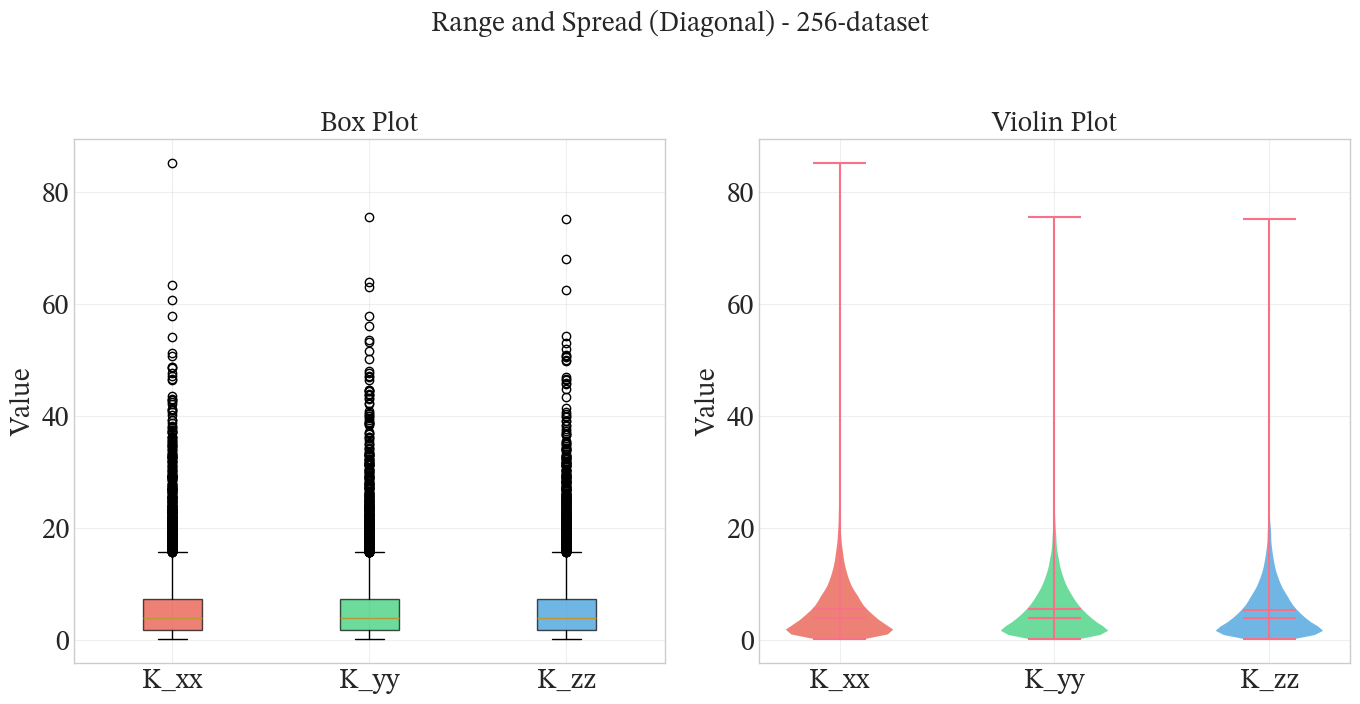

In [501]:
# Box and violin plots for diagonal - 256-final
plot_boxplot_violin_diag(df_256, '256-dataset')


/var/folders/56/q9j911z52w52_zzlftqnwln80000gn/T/ipykernel_20405/1443607857.py:236: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([df[col].dropna() for col in diag_cols],


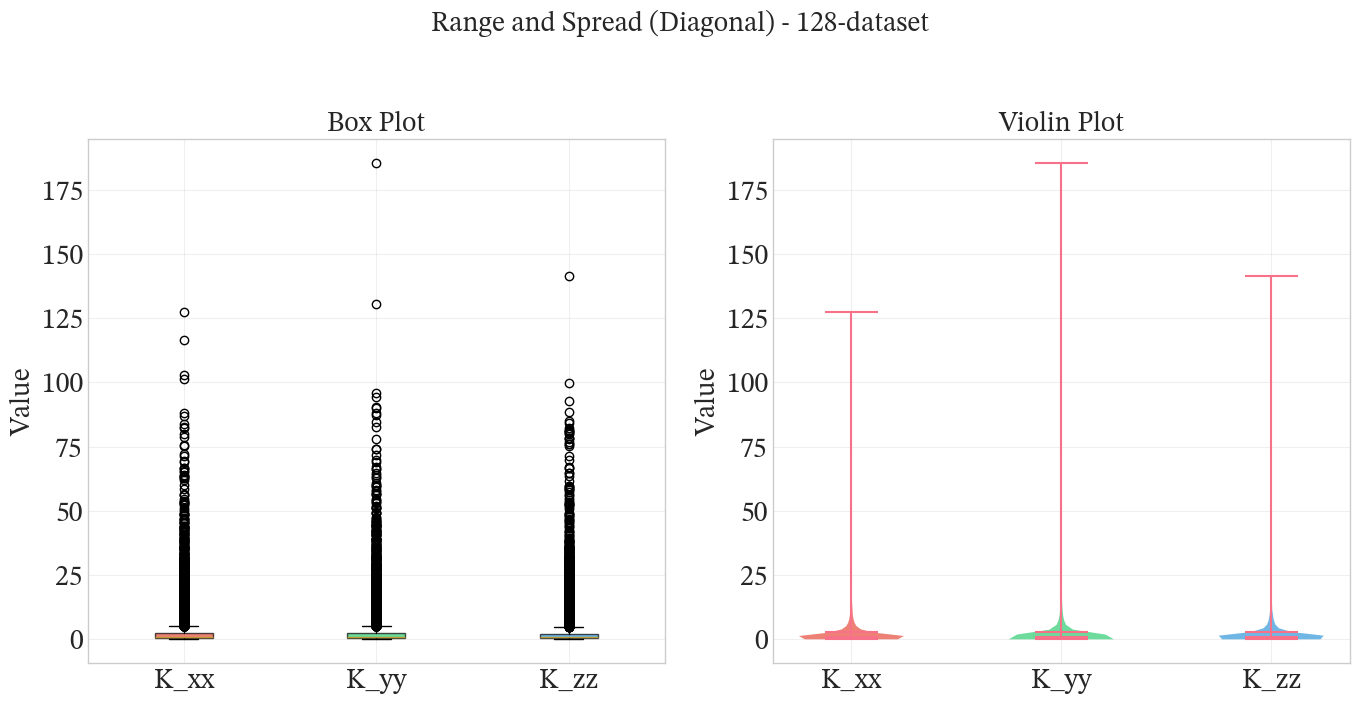

In [502]:
# Box and violin plots for diagonal - 128-final
plot_boxplot_violin_diag(df_feature, '128-dataset')


In [503]:
# Interesting structures for ParaView visualization
def find_interesting_structures(df, label, n=10):
    print(f'\n{"="*60}')
    print(f'INTERESTING STRUCTURES: {label}')
    print(f'{"="*60}')
    
    cols = ['sample_name', 'porosity', 'K_xx', 'K_yy', 'K_zz', 'K_xy', 'K_yz', 'K_xz']
    
    # 1. Highest permeability
    df['K_diag_mean'] = df[['K_xx','K_yy','K_zz']].mean(axis=1)
    print(f'\n--- Top {n} highest mean diagonal K ---')
    display(df.nlargest(n, 'K_diag_mean')[cols].reset_index(drop=True))
    
    # 2. Lowest permeability
    print(f'\n--- Top {n} lowest mean diagonal K ---')
    display(df.nsmallest(n, 'K_diag_mean')[cols].reset_index(drop=True))
    
    # 3. Most anisotropic (max/min diagonal ratio)
    df['aniso_ratio'] = df[['K_xx','K_yy','K_zz']].max(axis=1) / df[['K_xx','K_yy','K_zz']].min(axis=1)
    print(f'\n--- Top {n} most anisotropic (K_max/K_min) ---')
    display(df.nlargest(n, 'aniso_ratio')[cols + ['aniso_ratio']].reset_index(drop=True))
    
    # 4. Most isotropic (ratio closest to 1)
    print(f'\n--- Top {n} most isotropic (ratio ≈ 1) ---')
    display(df.nsmallest(n, 'aniso_ratio')[cols + ['aniso_ratio']].reset_index(drop=True))
    
    # 5. Largest off-diagonal (significant coupling)
    df['K_offdiag_max'] = df[['K_xy','K_yz','K_xz']].abs().max(axis=1)
    print(f'\n--- Top {n} largest off-diagonal component (directional coupling) ---')
    display(df.nlargest(n, 'K_offdiag_max')[cols + ['K_offdiag_max']].reset_index(drop=True))
    
    # 6. High porosity but low permeability (tortuous)
    high_poro = df[df['porosity'] > df['porosity'].quantile(0.75)]
    print(f'\n--- Top {n} high porosity but low K (tortuous paths) ---')
    display(high_poro.nsmallest(n, 'K_diag_mean')[cols].reset_index(drop=True))
    
    # 7. Low porosity but high permeability (well-connected)
    low_poro = df[df['porosity'] < df['porosity'].quantile(0.25)]
    print(f'\n--- Top {n} low porosity but high K (well-connected pores) ---')
    display(low_poro.nlargest(n, 'K_diag_mean')[cols].reset_index(drop=True))

find_interesting_structures(df_256, '256-final')
find_interesting_structures(df_feature, '128-final')



INTERESTING STRUCTURES: 256-final

--- Top 10 highest mean diagonal K ---


,sample_name,porosity,K_xx,K_yy,K_zz,K_xy,K_yz,K_xz
0,eps_0.02_coeffs_0.178_0.855_0.549_86.579_117.2...,0.620247,85.134543,75.577443,75.194065,1.520168,17.719805,1.114483
1,eps_0.02_coeffs_0.715_0.644_0.471_-5.122_17.32...,0.660376,57.920328,63.901637,68.089105,2.760605,4.585753,0.995084
2,eps_0.02_coeffs_0.908_0.409_0.653_-33.801_19.3...,0.694465,63.394156,62.995891,62.514178,1.147042,-2.059043,1.495348
3,eps_0.02_coeffs_0.233_0.512_0.676_43_116.4_221...,0.696350,60.727314,57.896723,50.946542,-0.862730,11.082538,-2.606741
4,eps_0.02_coeffs_0.909_1.407_0.345_-7.915_12.93...,0.697221,53.993886,56.075524,53.021450,-1.945148,0.829486,2.540771
5,eps_0.02_coeffs_0.953_1.282_0.873_-24.281_1.23...,0.698982,51.277039,51.658842,54.317445,-0.980620,-0.753450,0.291710
6,eps_0.02_coeffs_0.964_0.476_0.476_10.614_38.14...,0.684639,50.735263,53.130357,51.967899,0.241746,0.049575,0.591463
7,eps_0.02_coeffs_0.611_0.22_0.377_-13.731_30.97...,0.680108,48.711555,48.094277,49.786220,0.002909,-1.084525,-0.531672
8,eps_0.02_coeffs_0.998_1.093_0.275_4.5_7.288_83...,0.621748,48.486885,50.198017,46.420097,5.538108,-2.563007,0.104446
9,eps_0.02_coeffs_0.422_0.834_0.357_73.562_149.2...,0.647003,47.103409,43.970627,50.630624,-0.979444,-0.622008,1.282587



--- Top 10 lowest mean diagonal K ---


,sample_name,porosity,K_xx,K_yy,K_zz,K_xy,K_yz,K_xz
0,eps_0.02_coeffs_0.396_0.586_0.908_72.95_132.53...,0.641953,0.106992,0.106992,0.106992,1.919620e-13,9.341159e-14,1.840700e-14
1,eps_0.02_coeffs_0.606_0.244_0.299_89.116_112.1...,0.311134,0.148219,0.122694,0.115864,-1.794868e-02,-8.116852e-03,2.644839e-02
2,eps_0.02_coeffs_0.123_0.949_0.456_45.907_4.707...,0.505526,0.120115,0.112349,0.161136,3.251671e-03,-1.089391e-02,7.727998e-03
3,eps_0.02_coeffs_0.444_-0.671_0.712_23.204_119....,0.300780,0.142678,0.135680,0.139524,2.173786e-03,-1.625910e-03,2.293304e-03
4,eps_0.02_coeffs_0.493_0.264_0.29_79.117_118.45...,0.327716,0.137678,0.138626,0.141590,8.463424e-03,1.666692e-02,5.079779e-03
5,eps_0.02_coeffs_0.372_-0.333_0.695_95.588_131....,0.400894,0.135648,0.131025,0.155609,-6.927282e-03,-6.242445e-02,5.915567e-03
6,eps_0.02_coeffs_0.302_1.328_0.935_15.35_52.124...,0.328057,0.117277,0.161456,0.154158,-4.160210e-02,-1.967445e-02,1.782447e-02
7,eps_0.02_coeffs_0.716_0.979_0.389_54.949_140.9...,0.350914,0.148273,0.135298,0.168813,6.843902e-03,-2.367815e-03,4.618296e-03
8,eps_0.02_coeffs_0.452_0.437_0.941_44.373_134.8...,0.507740,0.127875,0.127875,0.200888,4.325139e-02,2.707365e-02,2.707373e-02
9,eps_0.02_coeffs_0.658_1.344_0.535_105.521_116....,0.592441,0.170212,0.146199,0.146199,1.748004e-02,4.745874e-02,1.748008e-02



--- Top 10 most anisotropic (K_max/K_min) ---


...

,sample_name,porosity,K_xx,K_yy,K_zz,K_xy,K_yz,K_xz,K_offdiag_max
0,eps_0.02_coeffs_0.965_0.579_0.78_50.281_43.836...,0.685977,82.515272,95.758177,82.468951,-7.244872,11.002423,-43.161249,43.161249
1,eps_0.02_coeffs_0.523_-0.054_0.445_8.048_43.22...,0.682683,80.013901,90.015659,80.574622,10.602343,5.106513,-32.527017,32.527017
2,eps_0.02_coeffs_0.674_1.43_0.938_-4.03_36.014_...,0.696804,59.967866,62.950643,70.004204,31.379239,9.814250,2.908020,31.379239
3,eps_0.02_coeffs_0.691_0.412_0.377_-10.913_45.5...,0.587080,43.663369,34.672603,41.407115,-30.497844,8.315709,-14.223638,30.497844
4,eps_0.02_coeffs_0.869_1.364_0.464_8.187_51.952...,0.681264,102.829242,185.317913,81.070327,-29.992295,8.841946,-0.107912,29.992295
5,eps_0.02_coeffs_0.964_0.881_0.657_52.391_61.48...,0.603095,35.977204,36.762971,17.052645,-26.713527,-0.106067,-1.004805,26.713527
6,eps_0.02_coeffs_0.303_0.74_0.579_7.214_53.781_...,0.687282,26.929448,27.241716,26.975753,-26.024050,26.132895,-26.073418,26.132895
7,eps_0.02_coeffs_0.637_1.221_0.387_35.406_41.78...,0.618106,35.890990,39.098024,12.080135,-24.922847,6.232892,-3.529229,24.922847
8,eps_0.02_coeffs_0.423_1.16_0.363_3.978_8.939_4...,0.655581,27.852274,46.890472,48.969562,-8.434485,-8.735972,23.800247,23.800247
9,eps_0.02_coeffs_0.954_0.425_0.937_-3.437_67.6_...,0.678575,38.781084,40.467251,34.066354,6.389874,-23.477413,-0.468082,23.477413



--- Top 10 high porosity but low K (tortuous paths) ---


,sample_name,porosity,K_xx,K_yy,K_zz,K_xy,K_yz,K_xz
0,eps_0.02_coeffs_0.433_1.173_0.316_6.101_19.28_...,0.620342,0.163289,0.178555,0.142553,-6.585567e-03,1.344891e-03,-0.003472
1,eps_0.02_coeffs_0.4_0.714_0.312_116.103_83.2_-...,0.635010,0.150320,0.208095,0.144682,-4.982310e-04,1.071324e-02,0.027517
2,eps_0.02_coeffs_0.543_1.357_0.429_97.772_83.81...,0.623857,0.209309,0.158054,0.138934,-1.337472e-03,1.838727e-02,0.007858
3,eps_0.02_coeffs_0.385_0.74_0.5_95.814_80.178_-...,0.645282,0.214499,0.161986,0.168689,6.314159e-03,-4.201337e-02,-0.015966
4,eps_0.02_coeffs_0.59_-0.018_0.797_96.941_143.4...,0.624536,0.182300,0.201317,0.198168,3.994220e-03,1.485827e-02,0.015731
5,eps_0.02_coeffs_0.67_0.539_0.732_109.988_142.1...,0.651474,0.221907,0.154114,0.224670,-3.056382e-02,-1.031334e-02,-0.038548
6,eps_0.02_coeffs_0.581_1.209_0.903_99.55_148.59...,0.646060,0.209436,0.215183,0.185861,6.848530e-02,2.067814e-02,-0.026044
7,eps_0.02_coeffs_0.642_0.834_0.422_53.635_77.90...,0.620701,0.188654,0.189200,0.251869,4.490951e-03,-2.030303e-02,-0.007021
8,eps_0.02_coeffs_0.651_0.417_0.867_70.84_141.98...,0.650359,0.278740,0.108392,0.278740,6.027202e-13,-9.375270e-08,-0.170348
9,eps_0.02_coeffs_0.471_-0.095_0.721_105.795_112...,0.621756,0.233391,0.249082,0.189171,3.184482e-03,4.108532e-02,0.010846



--- Top 10 low porosity but high K (well-connected pores) ---


,sample_name,porosity,K_xx,K_yy,K_zz,K_xy,K_yz,K_xz
0,eps_0.02_coeffs_0.442_0.917_0.339_-1.772_1.104...,0.376969,9.688823,32.274654,20.241840,-0.894076,-0.922543,0.587998
1,eps_0.02_coeffs_0.596_1.176_0.892_15.331_1.804...,0.408425,25.064263,21.765041,8.885433,-2.087630,-0.413541,5.247024
2,eps_0.02_coeffs_0.536_1.024_0.648_14.138_10.24...,0.344496,53.573300,0.838254,0.838254,0.065035,0.780838,0.065035
3,eps_0.02_coeffs_0.505_0.396_0.395_-3.256_19.31...,0.389681,17.029012,23.791180,10.639879,-4.106440,5.831008,-8.057166
4,eps_0.02_coeffs_0.752_1.034_0.492_7.238_26.257...,0.347500,18.445419,24.911235,7.518321,-4.546456,1.658487,-1.328619
5,eps_0.02_coeffs_0.62_1.407_0.381_8.823_23.853_...,0.373710,17.928571,4.448499,19.875659,-0.315740,-0.689339,1.156608
6,eps_0.02_coeffs_0.67_1.173_0.592_-1.993_52.099...,0.415243,10.455622,14.045759,17.708860,-2.790860,5.208620,-3.847953
7,eps_0.02_coeffs_0.68_0.7_0.692_2.987_35.767_73...,0.391531,14.237073,12.251264,13.331335,9.802409,-2.778452,-0.802057
8,eps_0.02_coeffs_0.904_1.374_0.428_-22.098_6.10...,0.389369,8.090219,7.097985,21.270994,-2.617065,-3.869849,-1.809496
9,eps_0.02_coeffs_0.768_1.447_0.679_-7.589_20.30...,0.399816,20.823182,7.968513,6.879457,2.690019,-0.962646,2.179561


In [504]:
# Sample names for each interesting category
def list_interesting_names(df, label, n=10):
    print(f'\n{"="*60}')
    print(f'SAMPLE NAMES: {label}')
    print(f'{"="*60}')
    
    df['K_diag_mean'] = df[['K_xx','K_yy','K_zz']].mean(axis=1)
    df['aniso_ratio'] = df[['K_xx','K_yy','K_zz']].max(axis=1) / df[['K_xx','K_yy','K_zz']].min(axis=1)
    df['K_offdiag_max'] = df[['K_xy','K_yz','K_xz']].abs().max(axis=1)
    
    categories = {
        'Highest mean diagonal K': df.nlargest(n, 'K_diag_mean')['sample_name'].tolist(),
        'Lowest mean diagonal K': df.nsmallest(n, 'K_diag_mean')['sample_name'].tolist(),
        'Most anisotropic': df.nlargest(n, 'aniso_ratio')['sample_name'].tolist(),
        'Most isotropic': df.nsmallest(n, 'aniso_ratio')['sample_name'].tolist(),
        'Largest off-diagonal': df.nlargest(n, 'K_offdiag_max')['sample_name'].tolist(),
        'High porosity, low K': df[df['porosity'] > df['porosity'].quantile(0.75)].nsmallest(n, 'K_diag_mean')['sample_name'].tolist(),
        'Low porosity, high K': df[df['porosity'] < df['porosity'].quantile(0.25)].nlargest(n, 'K_diag_mean')['sample_name'].tolist(),
    }
    
    for cat, names in categories.items():
        print(f'\n{cat}:')
        for name in names:
            print(f'  {name}')

list_interesting_names(df_256, '256-final')
list_interesting_names(df_feature, '128-final')

# Export to CSV
def export_interesting_names(df, label, n=10):
    df['K_diag_mean'] = df[['K_xx','K_yy','K_zz']].mean(axis=1)
    df['aniso_ratio'] = df[['K_xx','K_yy','K_zz']].max(axis=1) / df[['K_xx','K_yy','K_zz']].min(axis=1)
    df['K_offdiag_max'] = df[['K_xy','K_yz','K_xz']].abs().max(axis=1)
    
    val_cols = ['sample_name', 'porosity', 'K_xx', 'K_yy', 'K_zz', 'K_xy', 'K_yz', 'K_xz',
                'K_diag_mean', 'aniso_ratio', 'K_offdiag_max']
    
    selections = {
        'Highest mean diagonal K': df.nlargest(n, 'K_diag_mean'),
        'Lowest mean diagonal K': df.nsmallest(n, 'K_diag_mean'),
        'Most anisotropic': df.nlargest(n, 'aniso_ratio'),
        'Most isotropic': df.nsmallest(n, 'aniso_ratio'),
        'Largest off-diagonal': df.nlargest(n, 'K_offdiag_max'),
        'High porosity, low K': df[df['porosity'] > df['porosity'].quantile(0.75)].nsmallest(n, 'K_diag_mean'),
        'Low porosity, high K': df[df['porosity'] < df['porosity'].quantile(0.25)].nlargest(n, 'K_diag_mean'),
    }
    
    rows = []
    for cat, subset in selections.items():
        for rank, (_, row) in enumerate(subset.iterrows(), 1):
            entry = {'category': cat, 'rank': rank}
            for c in val_cols:
                entry[c] = row[c]
            rows.append(entry)
    
    out = pd.DataFrame(rows)
    fname = f'{label}_interesting_structures.csv'
    out.to_csv(fname, index=False)
    print(f'Saved: {fname}')

export_interesting_names(df_256, '256-final')
export_interesting_names(df_feature, '128-final')



SAMPLE NAMES: 256-final

Highest mean diagonal K:
  eps_0.02_coeffs_0.178_0.855_0.549_86.579_117.296_200.137_m_-0.394_rho_0.38_
  eps_0.02_coeffs_0.715_0.644_0.471_-5.122_17.32_459.58_m_-0.645_rho_0.34_
  eps_0.02_coeffs_0.908_0.409_0.653_-33.801_19.34_959.586_m_-0.642_rho_0.306_
  eps_0.02_coeffs_0.233_0.512_0.676_43_116.4_221.749_m_-0.511_rho_0.304_
  eps_0.02_coeffs_0.909_1.407_0.345_-7.915_12.938_-552.118_m_-0.636_rho_0.303_
  eps_0.02_coeffs_0.953_1.282_0.873_-24.281_1.231_49.824_m_-0.62_rho_0.301_
  eps_0.02_coeffs_0.964_0.476_0.476_10.614_38.143_-479.224_m_-0.599_rho_0.315_
  eps_0.02_coeffs_0.611_0.22_0.377_-13.731_30.972_165.913_m_-0.609_rho_0.32_
  eps_0.02_coeffs_0.998_1.093_0.275_4.5_7.288_834.158_m_-0.609_rho_0.378_
  eps_0.02_coeffs_0.422_0.834_0.357_73.562_149.281_261.645_m_-0.602_rho_0.353_

Lowest mean diagonal K:
  eps_0.02_coeffs_0.396_0.586_0.908_72.95_132.536_-799.225_m_-0.216_rho_0.358_
  eps_0.02_coeffs_0.606_0.244_0.299_89.116_112.153_-2374.669_m_-0.226_rho_0.6

---
# Summary: Sample Names for Reference
---

In [505]:
print("=" * 80)
print("SAMPLE NAMES FOR EASY REFERENCE")
print("=" * 80)

print("\n" + "-" * 40)
print("256-FINAL DATASET")
print("-" * 40)

print("\nLOW EXTREME SAMPLES (15):")
for i, name in enumerate(low_256['sample_name'].values, 1):
    print(f"  {i}. {name}")

print("\nHIGH EXTREME SAMPLES (15):")
for i, name in enumerate(high_256['sample_name'].values, 1):
    print(f"  {i}. {name}")

print("\n" + "-" * 40)
print("FEATURE_DATASET")
print("-" * 40)

print("\nLOW EXTREME SAMPLES (15):")
for i, name in enumerate(low_feature['sample_name'].values, 1):
    print(f"  {i}. {name}")

print("\nHIGH EXTREME SAMPLES (15):")
for i, name in enumerate(high_feature['sample_name'].values, 1):
    print(f"  {i}. {name}")

SAMPLE NAMES FOR EASY REFERENCE

----------------------------------------
256-FINAL DATASET
----------------------------------------

LOW EXTREME SAMPLES (15):
  1. eps_0.02_coeffs_0.396_0.586_0.908_72.95_132.536_-799.225_m_-0.216_rho_0.358_
  2. eps_0.02_coeffs_0.113_1.429_0.599_50.969_45.684_-891.744_m_-0.255_rho_0.501_
  3. eps_0.02_coeffs_0.394_-0.543_0.39_-15.881_81.884_-3702.134_m_-0.391_rho_0.582_
  4. eps_0.02_coeffs_0.621_-0.487_0.26_-6.454_129.215_-1222.046_m_-0.562_rho_0.7_
  5. eps_0.02_coeffs_0.391_-0.63_0.809_32.18_125.774_-3655.183_m_-0.202_rho_0.621_
  6. eps_0.02_coeffs_0.782_0.479_0.836_-34.869_29.016_-2152.514_m_-0.413_rho_0.551_
  7. eps_0.02_coeffs_0.329_-0.538_0.46_-38.676_114.779_-3533.862_m_-0.566_rho_0.31_
  8. eps_0.02_coeffs_0.465_-0.694_0.3_-39.898_52.463_-2457.931_m_-0.272_rho_0.499_
  9. eps_0.02_coeffs_0.142_-0.545_0.256_-7.511_2.53_-427.099_m_-0.448_rho_0.368_
  10. eps_0.02_coeffs_0.323_-0.01_0.844_-24.164_73.295_-1230.783_m_-0.356_rho_0.316_
  11. eps_

---
# Export All Results to Excel
---

In [506]:
# Export comprehensive results
with pd.ExcelWriter('permeability_analysis_results.xlsx', engine='openpyxl') as writer:
    # 256-final results
    stats_256.to_excel(writer, sheet_name='256-final_Statistics')
    low_256.to_excel(writer, sheet_name='256-final_Low_Extreme')
    high_256.to_excel(writer, sheet_name='256-final_High_Extreme')
    
    # 128-final results
    stats_feature.to_excel(writer, sheet_name='feature_Statistics')
    low_feature.to_excel(writer, sheet_name='feature_Low_Extreme')
    high_feature.to_excel(writer, sheet_name='feature_High_Extreme')

print("All results saved to: permeability_analysis_results.xlsx")
print("\nFiles generated:")
print("  - permeability_analysis_results.xlsx (comprehensive)")
print("  - 256-final_extreme_low_samples.csv")
print("  - 256-final_extreme_high_samples.csv")
print("  - 128-final_extreme_low_samples.csv")
print("  - 128-final_extreme_high_samples.csv")
print("  - Various PNG plots for each dataset")

ModuleNotFoundError: No module named 'openpyxl'